In [2]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))

if os.getcwd() != project_root:
    os.chdir(project_root)

if project_root not in sys.path:
    sys.path.append(project_root)

In [14]:
import pandas as pd
import time
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import norm 

from volatility_surface.core.calibration.calibrator import calibrate_snapshot, calibrate_global_essvi, calibrate_global_sabr, calibrate_global_essvi_update, summary, compare
from volatility_surface.core.calibration.objectives import get_objective
from volatility_surface.models.vol_models import get_model
from volatility_surface.plots.vol_plots import plot_surface, plot_slices, plot_total_variance, plot_metrics, plot_compare, plot_all
from time import time
import pandas as pd
pd.set_option('display.max_columns', None)
from volatility_surface.utils.arbitrage_checker import check_arbitrage, plot_arbitrage_map

def clean_df(path: str):
    """Cleans the market microstructure data
    #See if we only take otm options ? 'c' & k>0 otm calls, 'p' & k<0 otm puts

    Args:
        path (str): path of the file we want to use as the df 
    returns: pd.DataFrame
    """

    
    df = pd.read_csv(path)
    df = df[df.volume>0]
    put_boundary_mask = (df['underlying_price']*df['bid_price']<df['strike']) & (df['option_type']=='P')
    call_boundary_mask = (df['option_type']=='C') & (df['bid_price']<1)
    

    clean_df = df[put_boundary_mask | call_boundary_mask].copy()
    
    #Timestamp standardisation
    ts = clean_df.creation_timestamp_x.iloc[0]
    clean_df['creation_timestamp_x'] = ts
    clean_df['creation_timestamp_x'] = clean_df['creation_timestamp_x'] #2h, paris = gmt +2
    clean_df['expiration_timestamp'] = pd.to_datetime(df['expiration_timestamp'], format='%d%b%y')+pd.Timedelta(hours=8)
    clean_df['expiration_timestamp_ms'] = clean_df['expiration_timestamp'].astype('int64') / 10**6
    clean_df['file_timestamp'] = pd.to_datetime(clean_df['creation_timestamp_x'], unit='ms').dt.strftime('%Y-%m-%d %H:%M')

    #Features
    clean_df['mark_iv']= clean_df['mark_iv']/100
    clean_df['t'] = (clean_df['expiration_timestamp_ms']-clean_df['creation_timestamp_x'])/(3.6e6*24*365)
    clean_df['k'] = np.log(clean_df['strike']/clean_df['underlying_price'])
    clean_df['w'] = clean_df['mark_iv']**2 * clean_df['t'] 
    n_d1 = norm.pdf(-clean_df['k']/np.sqrt(clean_df['w']) + np.sqrt(clean_df['w'])/2) #Gatheral d1 formula, equivalent to classical one
    clean_df['vega'] = n_d1*np.sqrt(clean_df['t']) # Vega is to be multiplied by 1 vol point; Since we express vol as decimal, this is the adequate format
    #if we expressed vol as a percentage, we would divide vega by 100: e.g. 0.42 vol, 0.3 vega <=> 42 vol, 0.003 vega

    #OTM Filtering
    otm_call_mask = (clean_df.option_type=='C') & (clean_df.k >=0)
    otm_put_mask = (clean_df.option_type=='P') & (clean_df.k<=0)
    clean_df = clean_df[otm_call_mask | otm_put_mask]

    #IV Quotes
    clean_df[['bid_iv','ask_iv']] = clean_df.apply(implied_volatility_dataframe, axis=1, result_type='expand')
    clean_df.dropna(subset=['bid_iv','ask_iv'], inplace=True)
    clean_df['spread_iv'] = (clean_df['ask_iv'] - clean_df['bid_iv'])/2
    return clean_df



import glob
from pathlib import Path
def parquet_creation(underlying: str):
# Get all CSV files from data/ folder
    underlying=underlying.lower()
    csv_files = sorted(glob.glob(f'data/{underlying}/*.csv'))

    # Load and clean all CSV files
    global_df = pd.concat([clean_df(file) for file in csv_files], ignore_index=True)

    # Save to parquet
    global_df.to_parquet(f'data/parquets/{underlying}_options_data_cleaned.parquet')

eth_df = pd.read_parquet('2 - Data/parquets/eth_options_data_cleaned.parquet')
btc_df = pd.read_parquet('2 - Data/parquets/btc_options_data_cleaned.parquet')


eth_snapshots = {}
for t0 in eth_df.file_timestamp.unique():
    eth_snapshot = eth_df[eth_df.file_timestamp == t0]
    eth_snapshots[f'eth {eth_snapshot.file_timestamp.unique()[0]}'] = eth_snapshot
eth_dates = eth_snapshots.keys()

btc_snapshots = {}
for t0 in btc_df.file_timestamp.unique():
    btc_snapshot = btc_df[btc_df.file_timestamp == t0]
    btc_snapshots[f'btc {btc_snapshot.file_timestamp.unique()[0]}'] = btc_snapshot



In [22]:
obj = get_objective('vega_wmse')

comparison_dict = {}
eth_cal_arb_vio = {'Raw SVI':0,'eSSVI':0,'SABR':0}
btc_cal_arb_vio = {'Raw SVI':0,'eSSVI':0,'SABR':0}

eth_average_hit_rate = {'Raw SVI':0,'eSSVI':0,'SABR':0}
btc_average_hit_rate = {'Raw SVI':0,'eSSVI':0,'SABR':0}
for date, snapshot in eth_snapshots.items():
    svi_vwmse = calibrate_snapshot(df=snapshot, model=get_model('svi'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)
    sabr_vwmse = calibrate_snapshot(df=snapshot, model=get_model('sabr'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)
    essvi_vwmse = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=obj, bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)

    comparison = compare(svi_vwmse, sabr_vwmse, essvi_vwmse)
    comparison_dict[date[4:14]] = comparison
    eth_cal_arb_vio['Raw SVI'] += comparison.cal_arb_viol['Raw SVI']
    eth_cal_arb_vio['eSSVI'] += comparison.cal_arb_viol['eSSVI']
    eth_cal_arb_vio['SABR'] += comparison.cal_arb_viol['SABR']

    eth_average_hit_rate['Raw SVI'] += comparison.spread_hit_rate['Raw SVI']
    eth_average_hit_rate['eSSVI'] += comparison.spread_hit_rate['eSSVI']
    eth_average_hit_rate['SABR'] += comparison.spread_hit_rate['SABR']

                objective   iv_rmse  iv_rrmse  spread_hit_rate    w_rmse  cal_arb_viol  atm_smoothness
model                                                                                                 
Raw SVI  obj_iv_vega_wmse  0.004334  0.006741         0.911780  0.000631           0.0        0.021456
SABR     obj_iv_vega_wmse  0.026912  0.049592         0.496845  0.004978           0.0        0.021176
eSSVI    obj_iv_vega_wmse  0.027464  0.039764         0.658887  0.003523           0.0        0.020918
                objective   iv_rmse  iv_rrmse  spread_hit_rate    w_rmse  cal_arb_viol  atm_smoothness
model                                                                                                 
Raw SVI  obj_iv_vega_wmse  0.012534  0.011953         0.891843  0.002294           0.0        0.055484
SABR     obj_iv_vega_wmse  0.014492  0.015535         0.818267  0.002089           0.0        0.055871
eSSVI    obj_iv_vega_wmse  0.030393  0.030420         0.651272  0.003729 

In [23]:
import pickle
with open('comparison_dict.pkl', 'wb') as f:
    pickle.dump(comparison_dict, f)

with open('eth_cal_arb_vio.pkl', 'wb') as f:
    pickle.dump(eth_cal_arb_vio, f)

with open('eth_average_hit_rate.pkl', 'wb') as f:
    pickle.dump(comparison_dict, f)

In [26]:
comparison_dict.keys()

dict_keys(['2026-06-04', '2026-06-05', '2026-06-08', '2026-05-21', '2026-05-22', '2026-05-27', '2026-05-28', '2026-06-02'])

In [36]:
comparison_dict['2026-06-04'].spread_hit_rate

model
Raw SVI    0.911780
SABR       0.496845
eSSVI      0.658887
Name: spread_hit_rate, dtype: float64

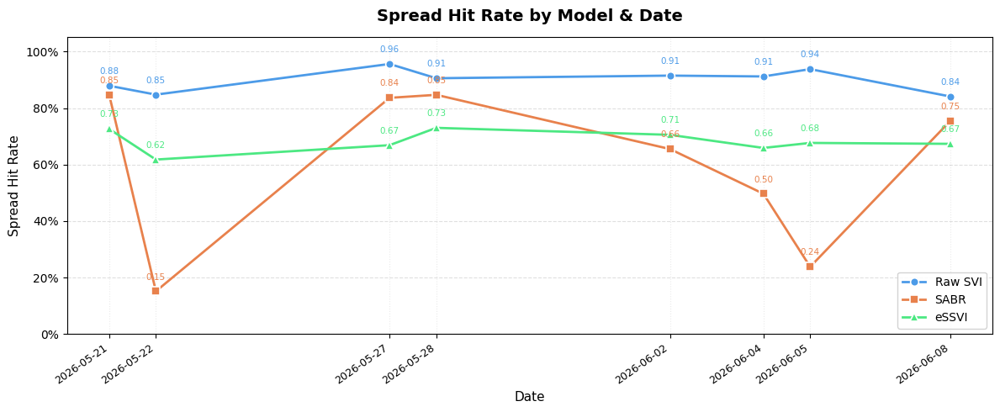

Saved → spread_hit_rate.png


In [37]:
import pickle
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Load the data
with open('comparison_dict.pkl', 'rb') as f:
    comparison_dict = pickle.load(f)

# Extract dates and hit rates per model
dates = sorted(comparison_dict.keys())
dates_dt = [datetime.strptime(d, '%Y-%m-%d') for d in dates]

models = ['Raw SVI', 'SABR', 'eSSVI']
colors  = {'Raw SVI': '#4C9BE8', 'SABR': '#E8814C', 'eSSVI': '#4CE882'}
markers = {'Raw SVI': 'o',        'SABR': 's',        'eSSVI': '^'}

hit_rates = {m: [] for m in models}

for date in dates:
    hr = comparison_dict[date].spread_hit_rate
    for model in models:
        hit_rates[model].append(hr[model])

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for model in models:
    ax.plot(
        dates_dt, hit_rates[model],
        label=model,
        color=colors[model],
        marker=markers[model],
        linewidth=2,
        markersize=7,
        markeredgewidth=1.2,
        markeredgecolor='white',
    )
    # Annotate each point with its value
    for x, y in zip(dates_dt, hit_rates[model]):
        ax.annotate(
            f'{y:.2f}',
            xy=(x, y),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            fontsize=7.5,
            color=colors[model],
        )

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator())
plt.xticks(dates_dt, rotation=35, ha='right', fontsize=9)

ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

ax.set_title('Spread Hit Rate by Model & Date', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Spread Hit Rate', fontsize=11)
ax.legend(fontsize=10, framealpha=0.85)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', linestyle=':', alpha=0.25)

plt.tight_layout()
plt.savefig('spread_hit_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → spread_hit_rate.png")

In [39]:
eth_snapshots

{'eth 2026-06-04 20:06':      bid_price  ask_price  open_interest  mark_price  creation_timestamp_x  \
 0       0.0060     0.0070           55.2    0.006525         1780603595805   
 1       0.0022     0.0026         1462.6    0.002329         1780603595805   
 2       0.0070     0.0075         2412.9    0.007010         1780603595805   
 3       0.0002     0.0005         1216.7    0.000325         1780603595805   
 4       0.1285     0.1310          907.6    0.129353         1780603595805   
 ..         ...        ...            ...         ...                   ...   
 400     0.0044     0.0048         3671.1    0.004614         1780603595805   
 401     0.0011     0.0014          146.0    0.001178         1780603595805   
 402     0.0570     0.0580          483.4    0.057239         1780603595805   
 403     0.0023     0.0027           75.1    0.002583         1780603595805   
 404     0.0125     0.0135           85.2    0.013042         1780603595805   
 
      volume  mark_iv  und

In [46]:
eth_snapshots.keys()

dict_keys(['eth 2026-06-04 20:06', 'eth 2026-06-05 07:50', 'eth 2026-06-05 11:52', 'eth 2026-06-08 11:49', 'eth 2026-05-21 13:41', 'eth 2026-05-21 13:42', 'eth 2026-05-21 13:43', 'eth 2026-05-21 13:44', 'eth 2026-05-21 13:45', 'eth 2026-05-22 14:42', 'eth 2026-05-27 11:26', 'eth 2026-05-27 11:43', 'eth 2026-05-28 09:42', 'eth 2026-06-02 07:26'])

In [ ]:
sabr_weird = calibrate_snapshot(df=eth_snapshots['eth 2026-05-22 14:42'], model=get_model('sabr'), objective=get_objective('vega_wmse'), bid_col = 'bid_iv', ask_col='ask_iv', verbose=False)


KeyError: 'eth 2026-05-22'

In [49]:
sabr_weird_arbfree = calibrate_snapshot(df=eth_snapshots['eth 2026-05-22 14:42'], model=get_model('sabr'), objective=get_objective('vega_wmse'), bid_col = 'bid_iv', ask_col='ask_iv', verbose=False, enforce_arbfree=True)

(<Figure size 1200x700 with 2 Axes>,
 <Figure size 1650x1680 with 24 Axes>,
 <Figure size 1000x500 with 2 Axes>,
 <Figure size 2000x400 with 4 Axes>)

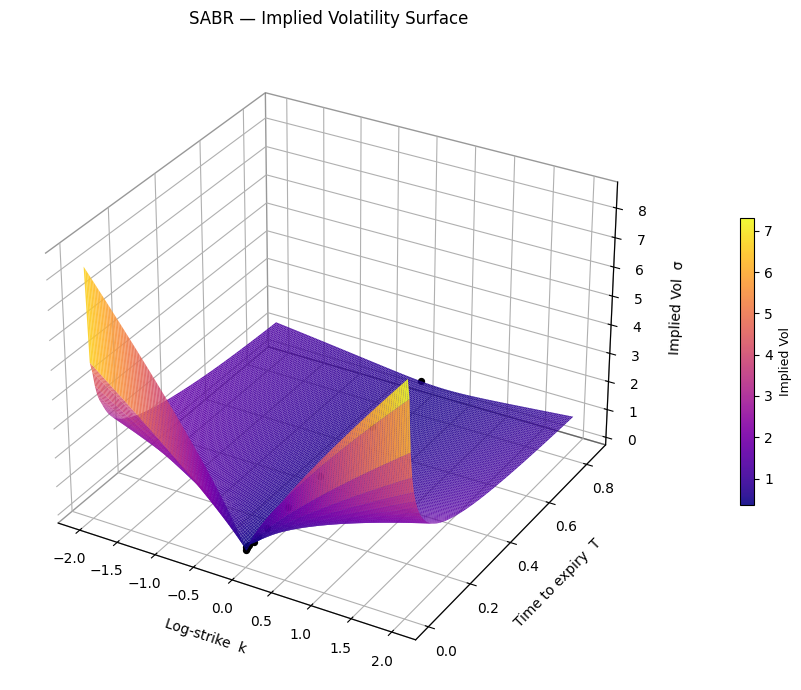

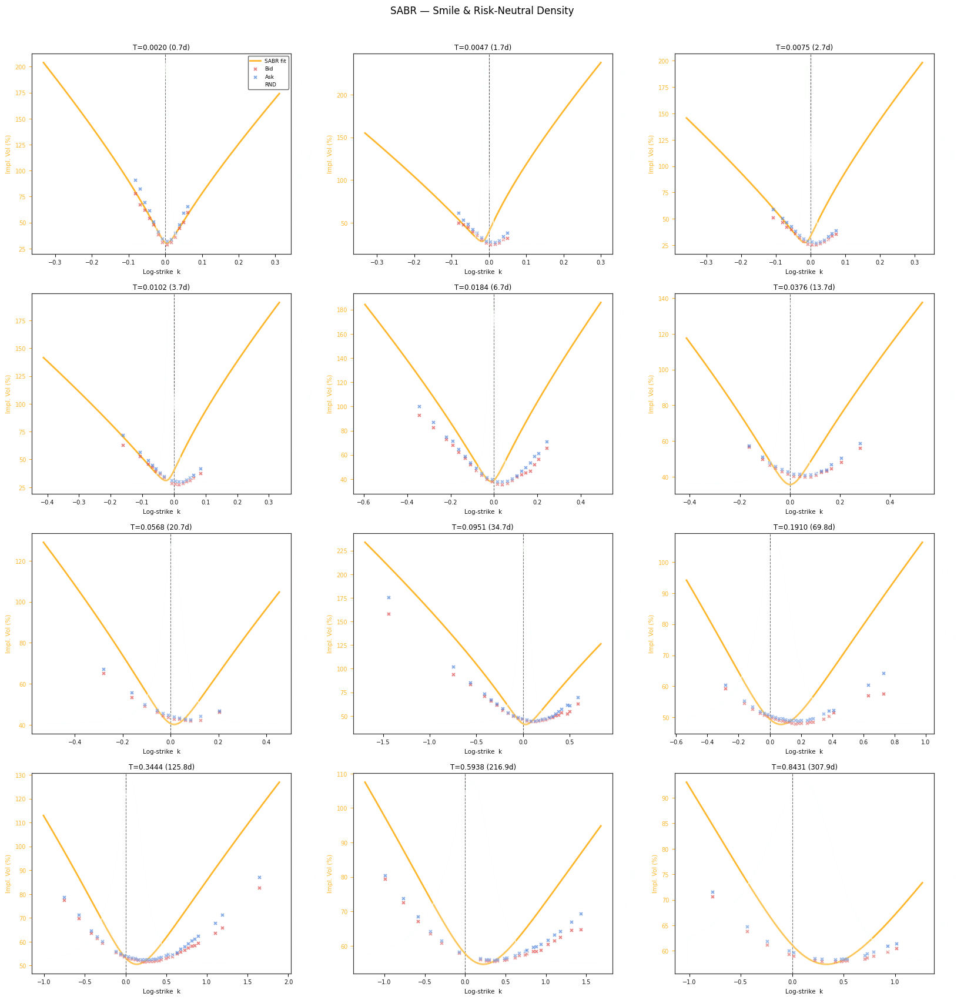

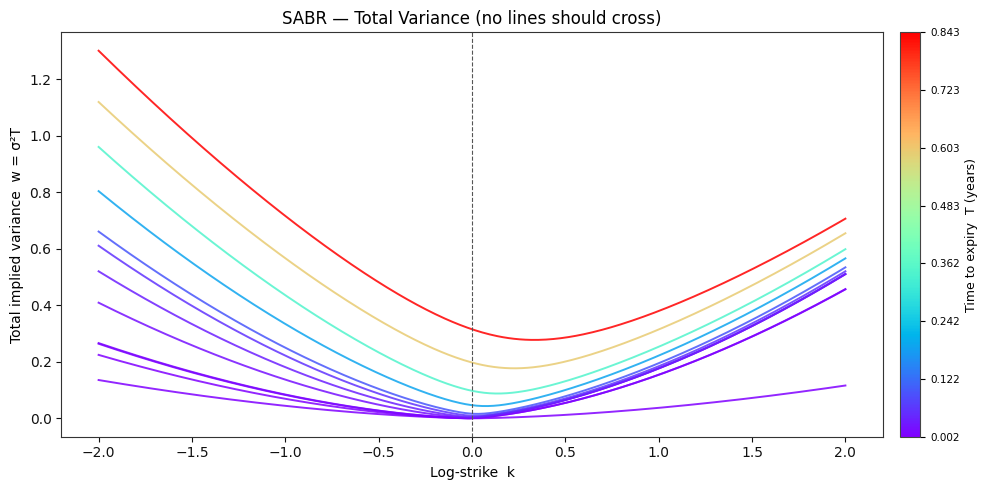

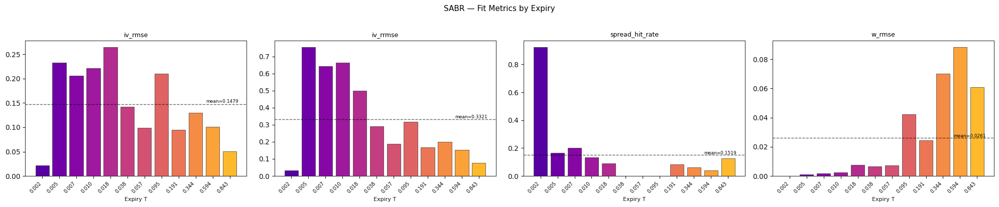

In [ ]:
plot_all(sabr_weird, df=eth_snapshots['eth 2026-05-22 14:42']);

In [51]:

for t, p in zip(sabr_weird['expiries'], sabr_weird['params']):
    print(f"T={t:.4f}  alpha={p['alpha']:.3f}  rho={p['rho']:+.3f}  nu={p['nu']:.3f}")

T=0.0020  alpha=0.287  rho=-0.218  nu=21.321
T=0.0047  alpha=0.389  rho=+0.783  nu=23.579
T=0.0075  alpha=0.313  rho=+0.656  nu=17.938
T=0.0102  alpha=0.377  rho=+0.708  nu=15.221
T=0.0184  alpha=0.338  rho=+0.265  nu=10.458
T=0.0376  alpha=0.306  rho=-0.020  nu=7.243
T=0.0568  alpha=0.354  rho=-0.171  nu=5.760
T=0.0951  alpha=0.370  rho=-0.211  nu=4.267
T=0.1910  alpha=0.454  rho=-0.299  nu=2.793
T=0.3444  alpha=0.503  rho=-0.361  nu=1.963
T=0.5938  alpha=0.560  rho=-0.370  nu=1.358
T=0.8431  alpha=0.607  rho=-0.397  nu=1.074


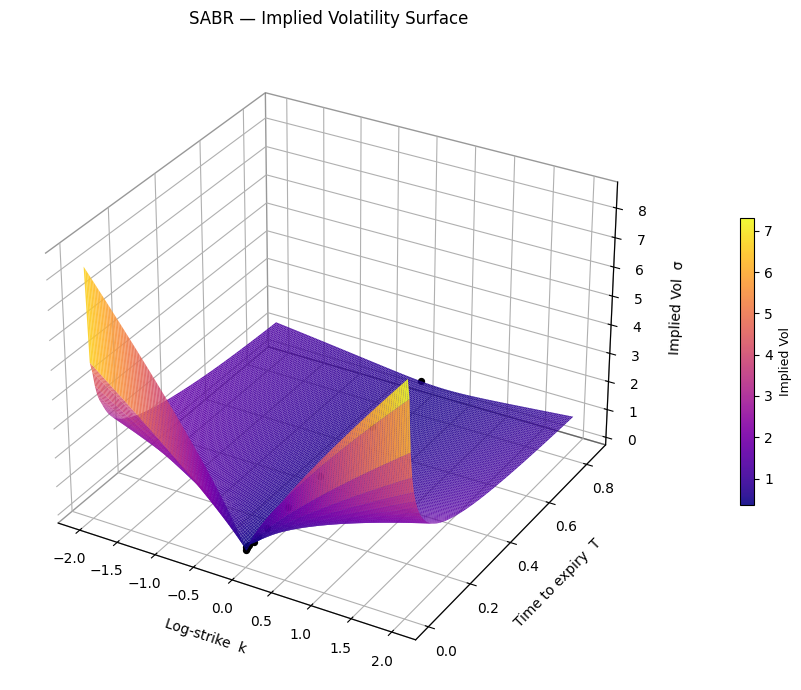

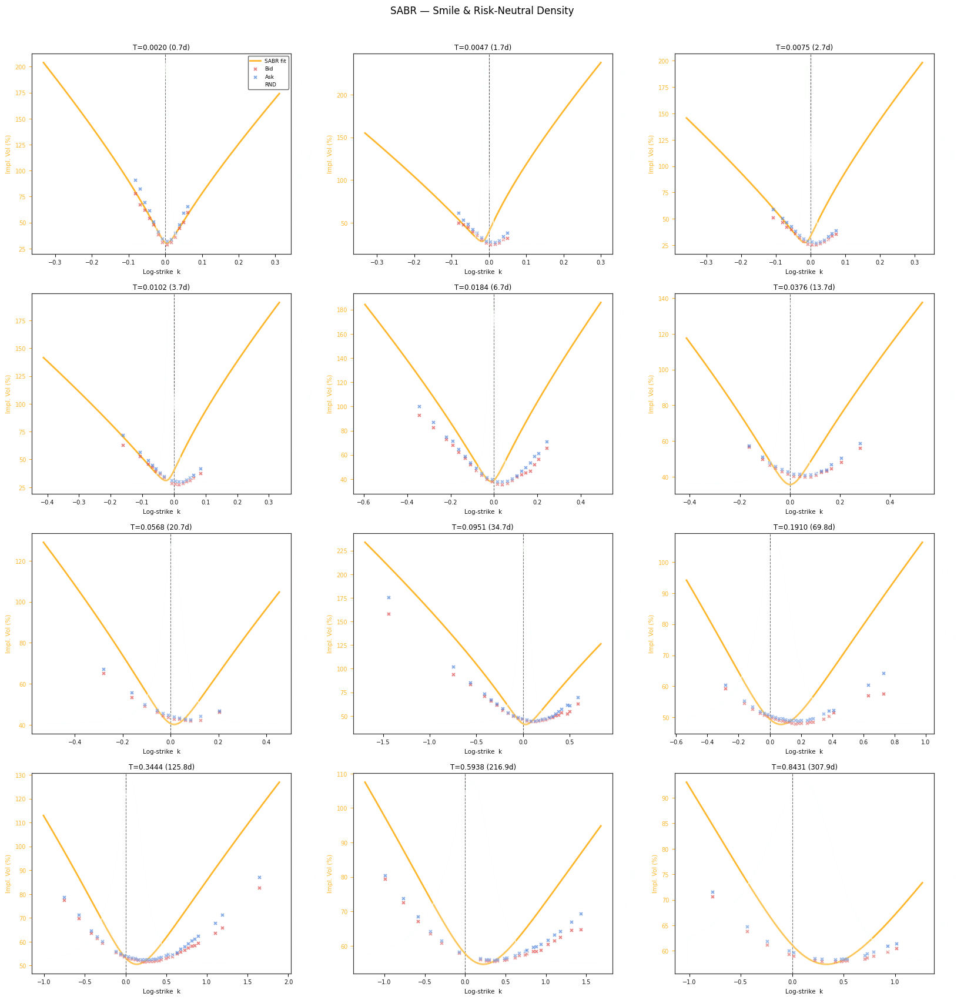

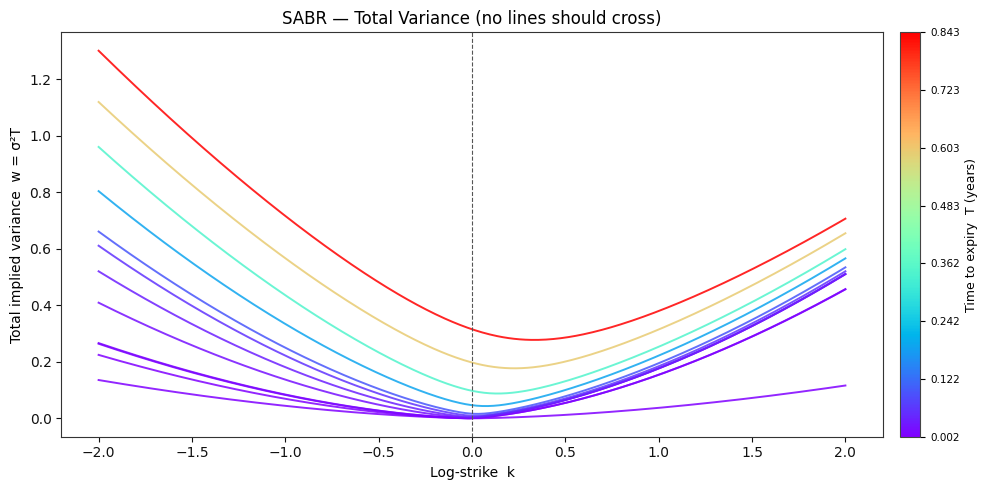

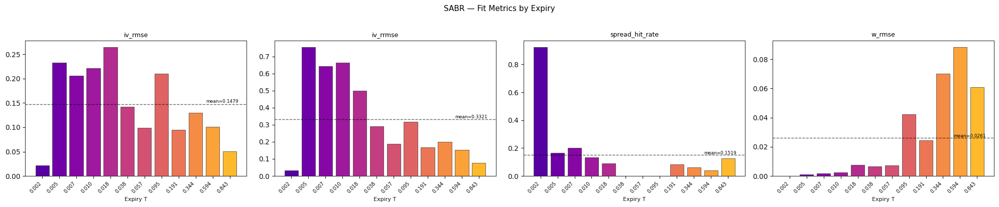

In [50]:
plot_all(sabr_weird_arbfree, df=eth_snapshots['eth 2026-05-22 14:42']);

In [ ]:

from calibrator import calibrate_global_essvi
obj1 = make_zone_wmse(atm_threshold=0.2, atm_boost=1) #base case, 0 breaks it since it's a mult
obj3 = make_zone_wmse(atm_threshold = 0.2, atm_boost=3)
obj5 = make_zone_wmse(atm_threshold=0.2, atm_boost=5)
result_essvi_1 = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=obj1, verbose=False)
result_essvi_5 = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=obj5, verbose=False)
result_essvi_3 = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=obj3, verbose=False)
# obj1 = make_zone_wmse(atm_threshold=0.15, wing_weight=1)
# result_essvi_w1 = calibrate_global_essvi(df=snapshot, model=get_model('essvi'),objective=obj1, verbose=False)

In [22]:
result_essvi = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=get_objective('iv_rmse'), verbose=False)
result_essvi_vw = calibrate_global_essvi(df=snapshot, model=get_model('essvi'), objective=get_objective('vega_wmse'), verbose=False)

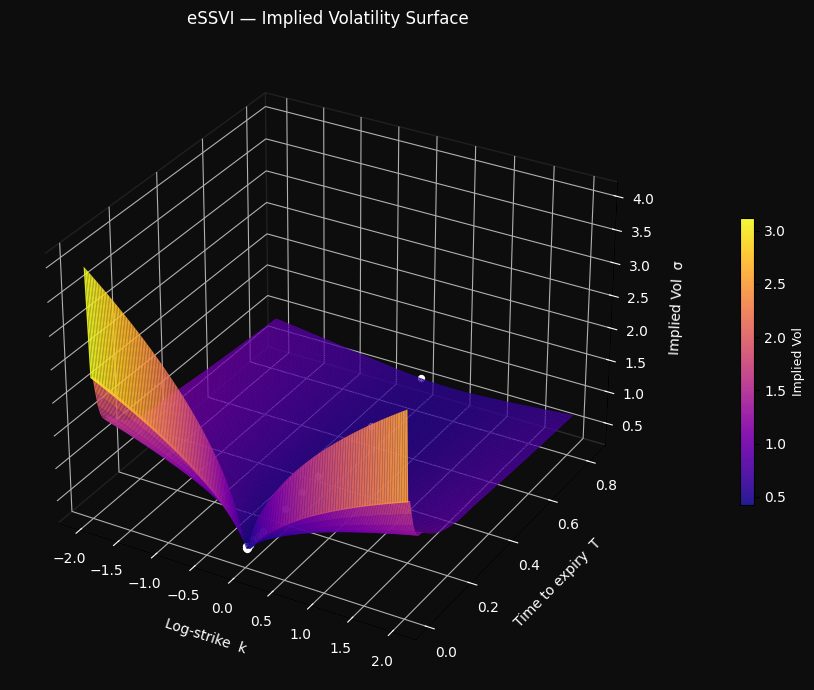

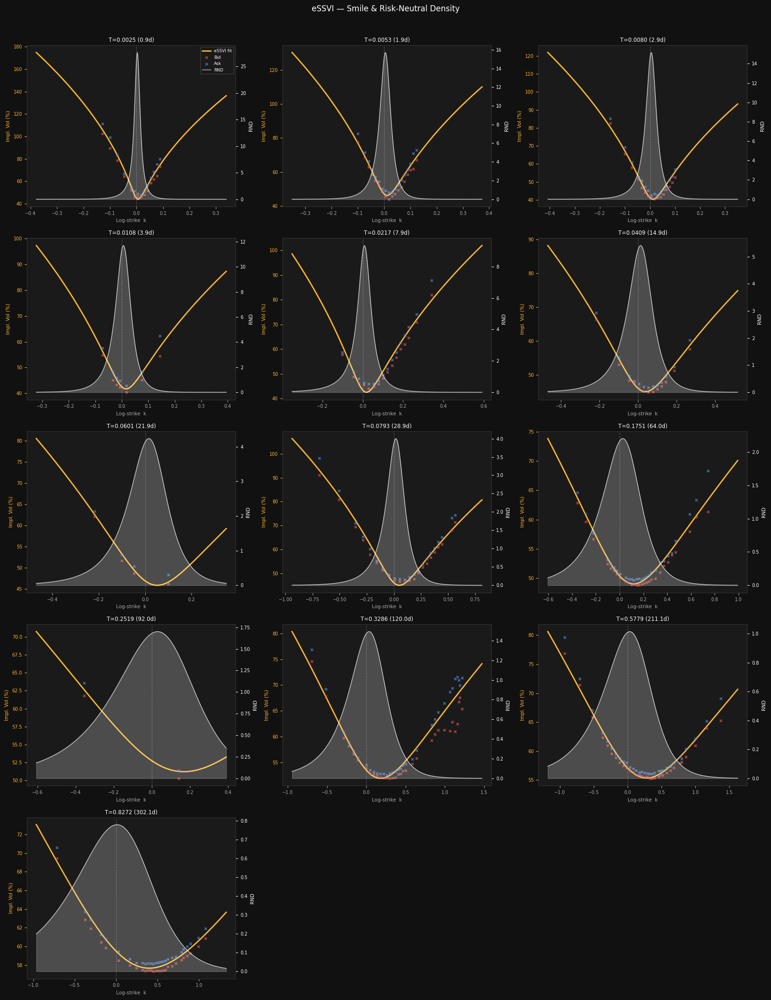

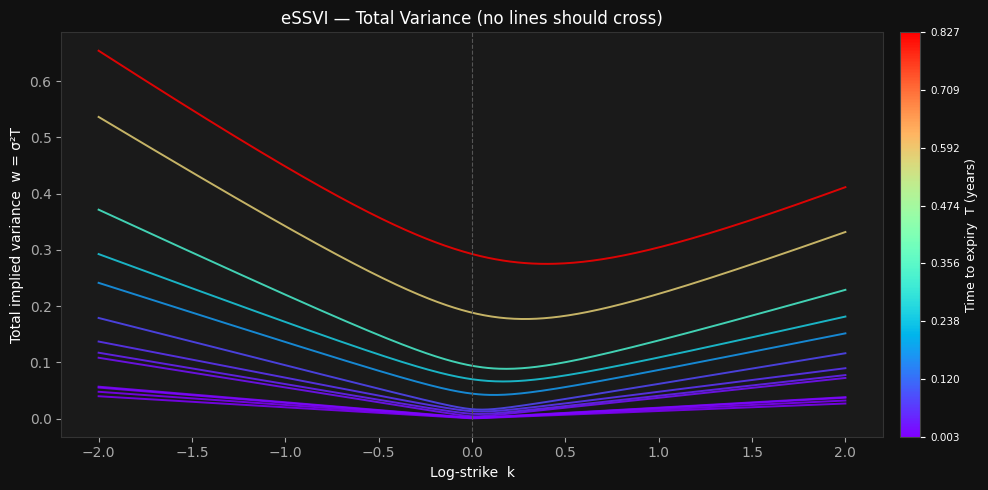

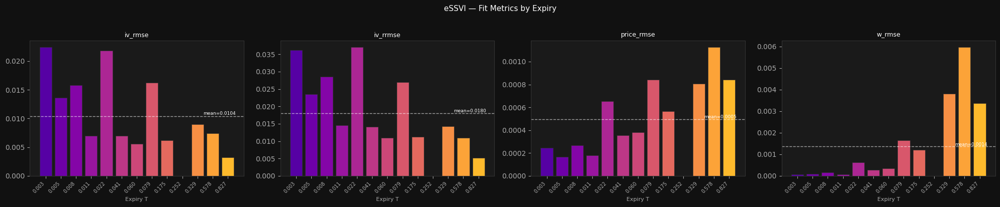

In [21]:
plot_all(result_essvi,df=snapshot); #IV RMSE

By excluding  all options that have not been traded in the last 24 hours, 

Raw
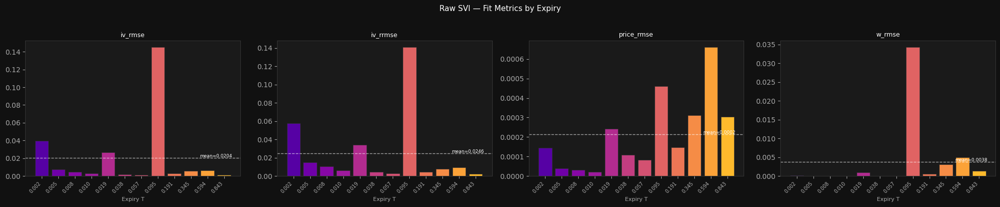

Volume-Filtered : 
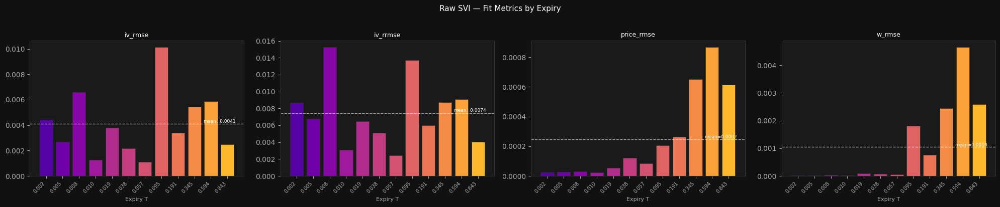

IV RMSE : Reduced by 80% \
IV RRMSE : Reduced by 70% \
Price RMSE: no change -> makes sense because iv improving by 80% on a few percent is extremely small : vega isn't large enough generally to warrant a large change \
W Rmse : Improved by 75%

# MODEL COMPARISON 

In [24]:
models = ['svi','ssvi','essvi','sabr'] 
dict_results = {}
for model in models:
    for obj in ['iv_rmse', 'vega_wmse']:
        match model:
            case 'essvi':
                dict_results[f'{model}_{obj}'] = calibrate_global_essvi(df=snapshot, model=get_model(model), objective=get_objective(obj),verbose=False)
            case 'ssvi':
                dict_results[f'{model}_{obj}'] = calibrate_global_ssvi(df=snapshot, model=get_model(model), objective=get_objective(obj),verbose=False)
            case 'sabr':
                dict_results[f'{model}_{obj}'] = calibrate_snapshot(df=snapshot, model=get_model(model), objective=get_objective(obj),verbose=False)
            case 'svi':
                dict_results[f'{model}_{obj}'] = calibrate_snapshot(df=snapshot, model=get_model(model), objective=get_objective(obj),verbose=False)



## IV RMSE METRIC

(<Figure size 1200x700 with 2 Axes>,
 <Figure size 1650x2100 with 28 Axes>,
 <Figure size 1000x500 with 2 Axes>,
 <Figure size 2000x400 with 4 Axes>)

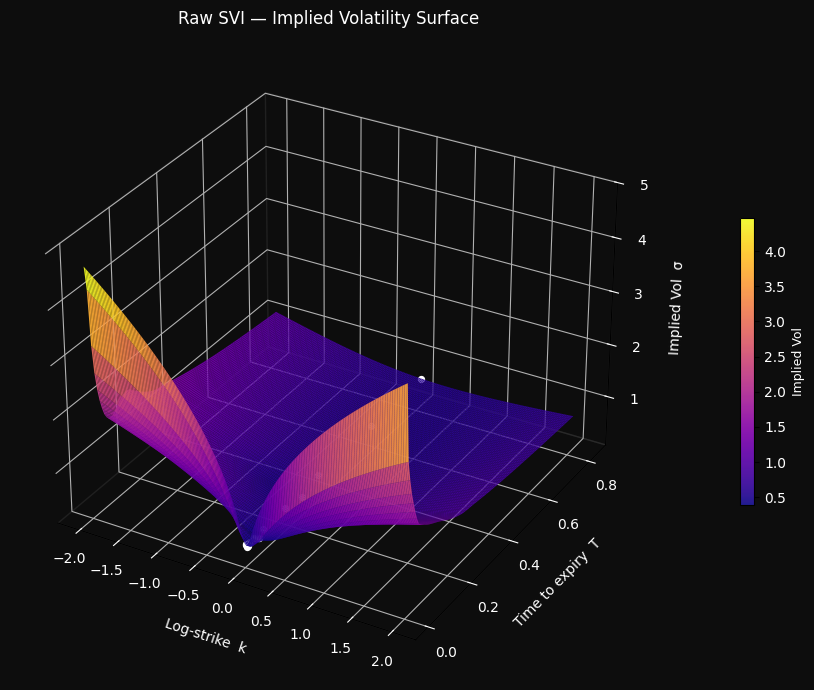

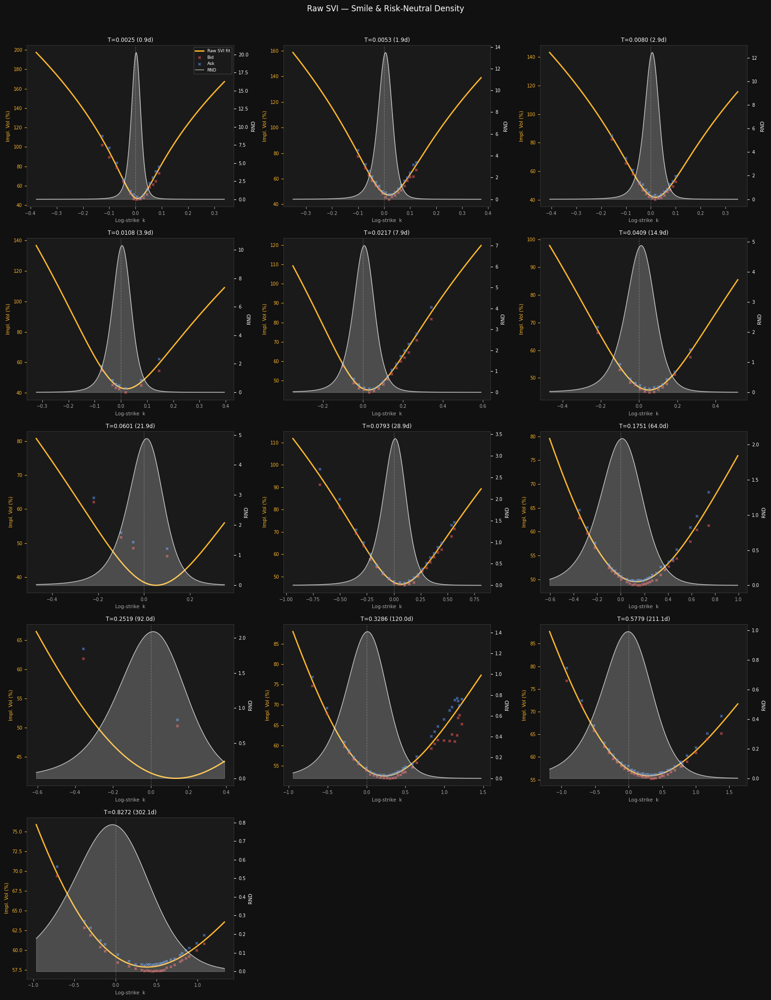

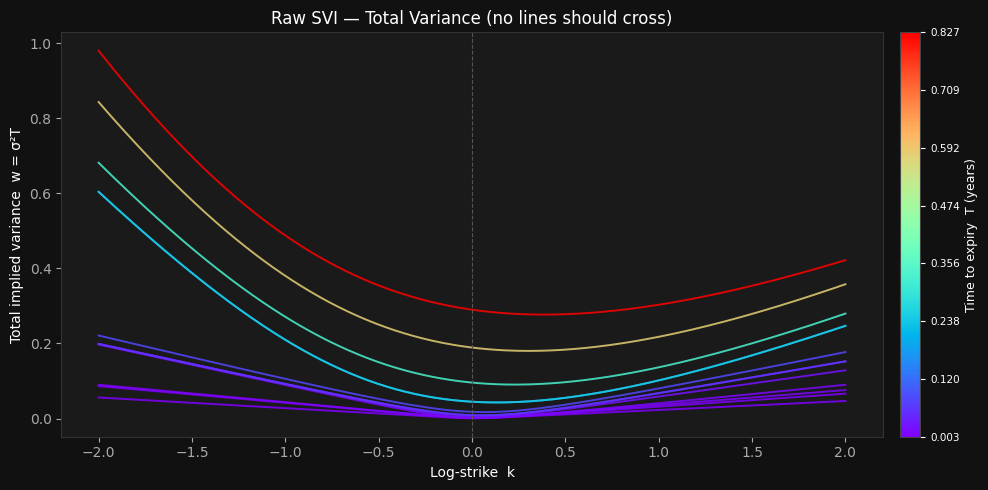

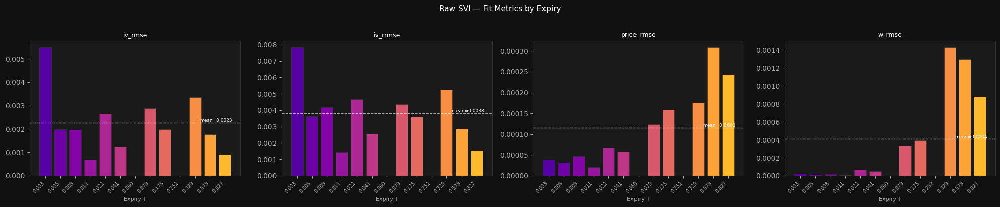

In [32]:
plot_all(dict_results['svi_iv_rmse'], df=snapshot);

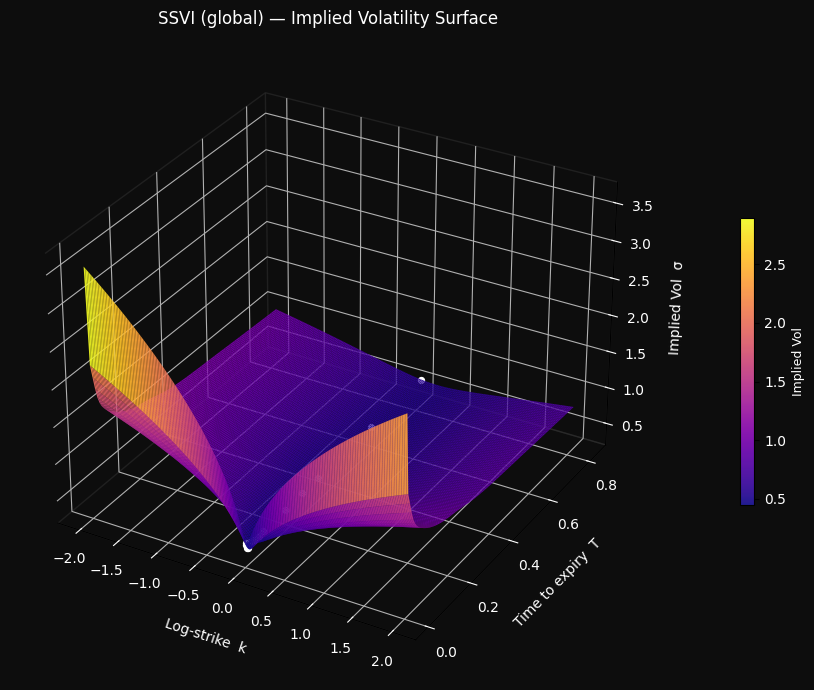

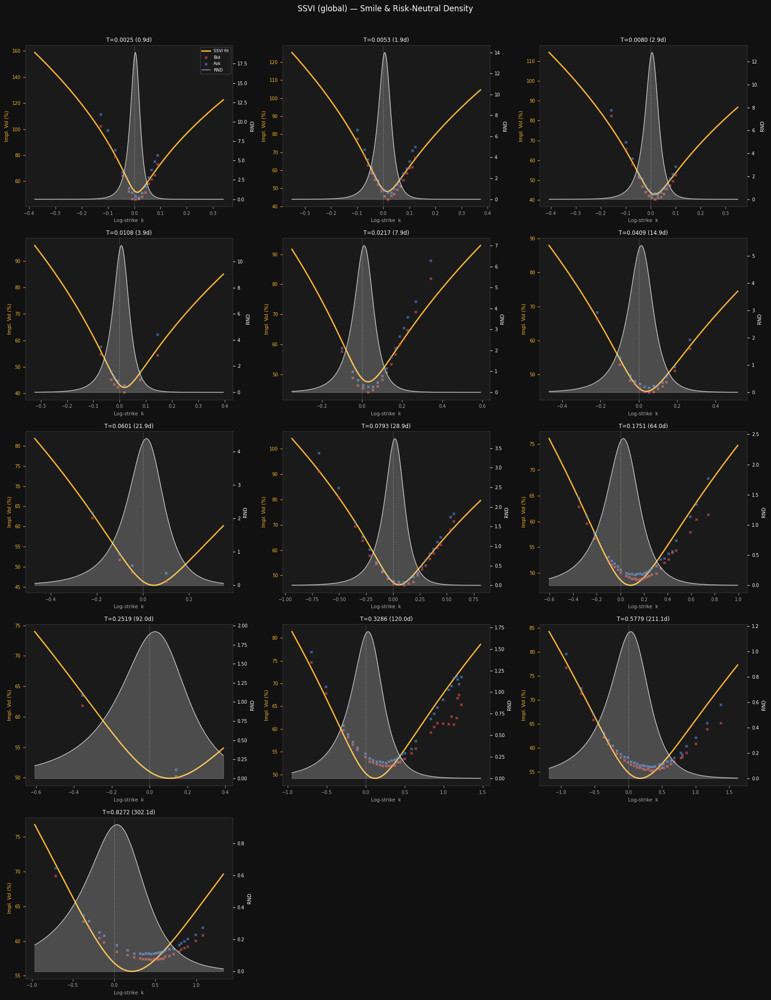

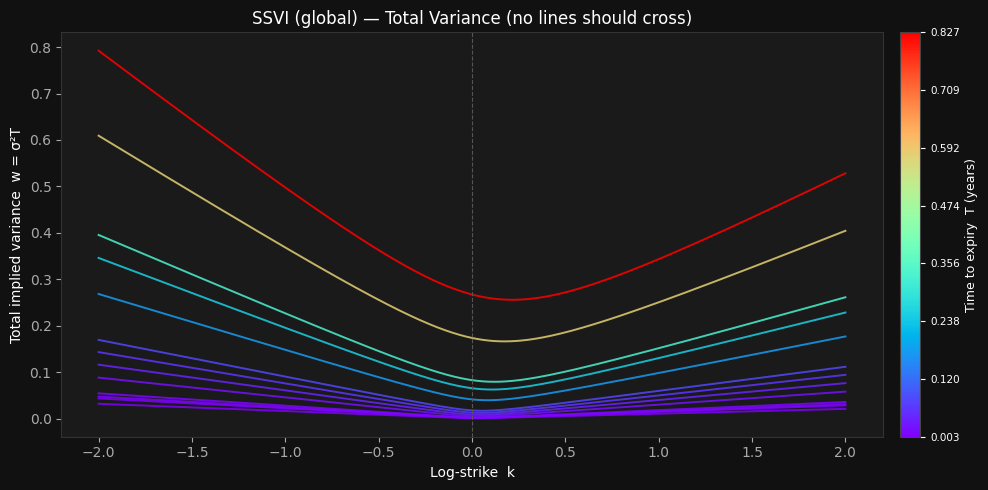

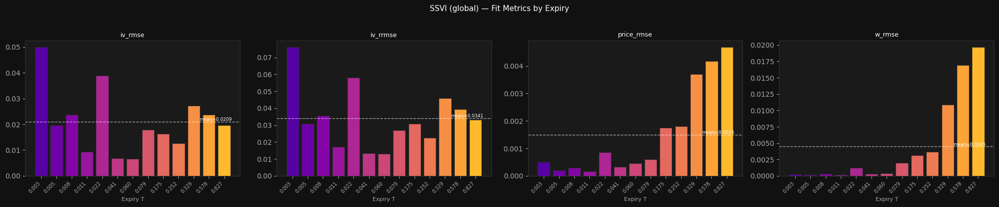

In [33]:
plot_all(dict_results['ssvi_iv_rmse'], df=snapshot);

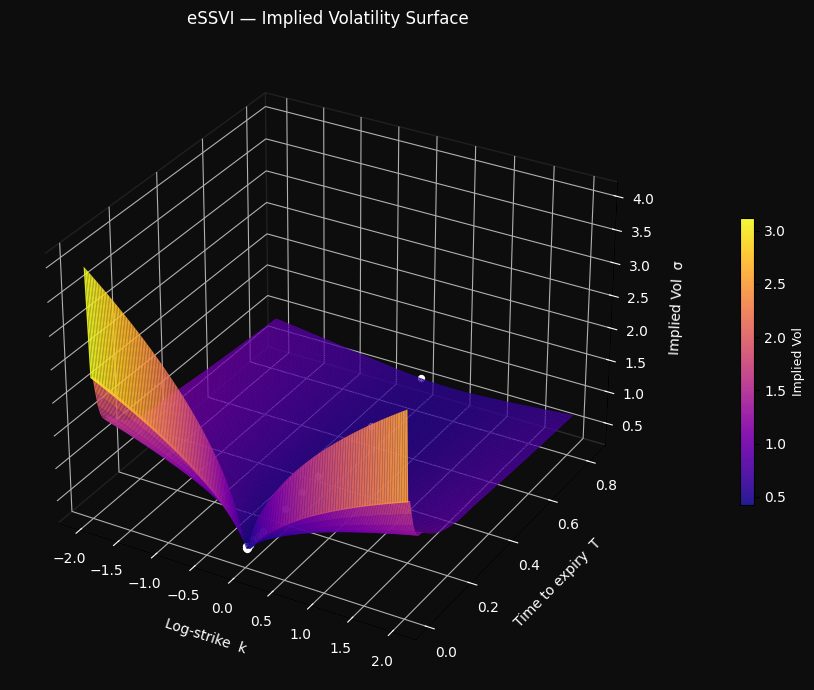

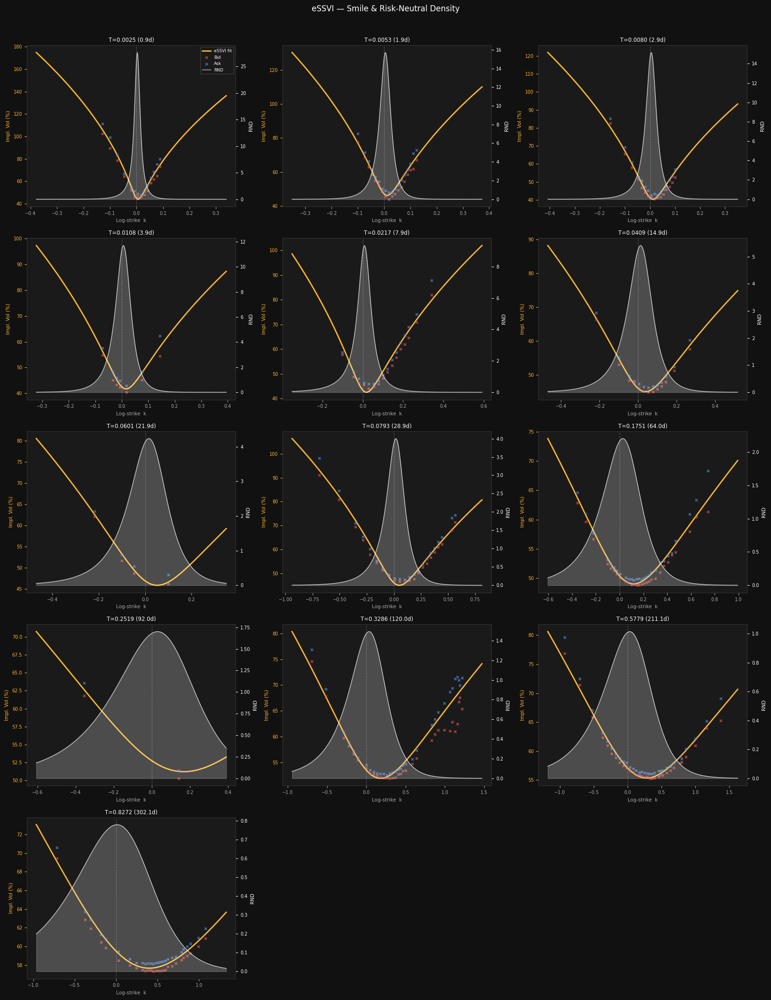

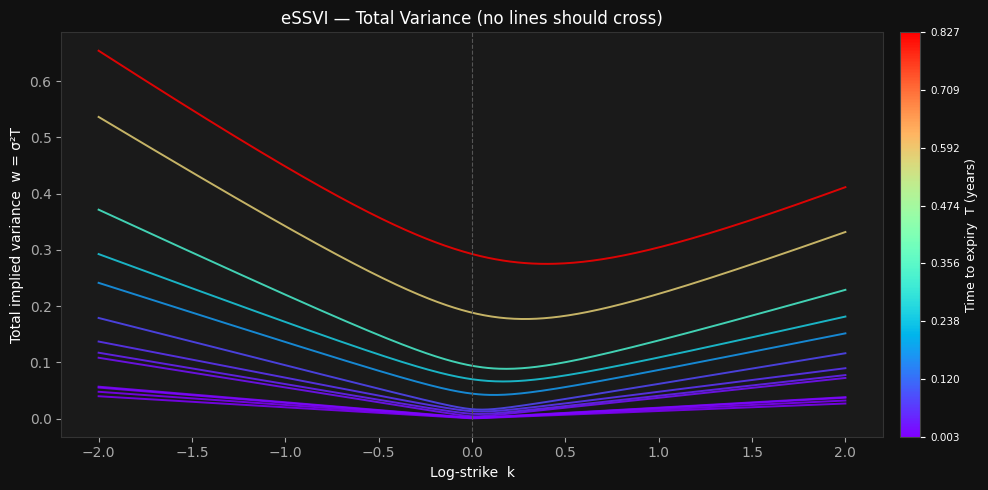

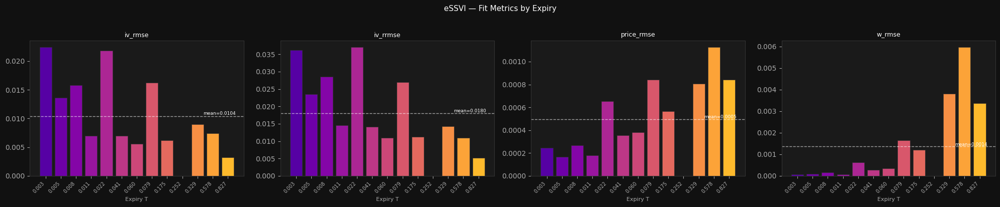

In [34]:
plot_all(dict_results['essvi_iv_rmse'], df=snapshot);

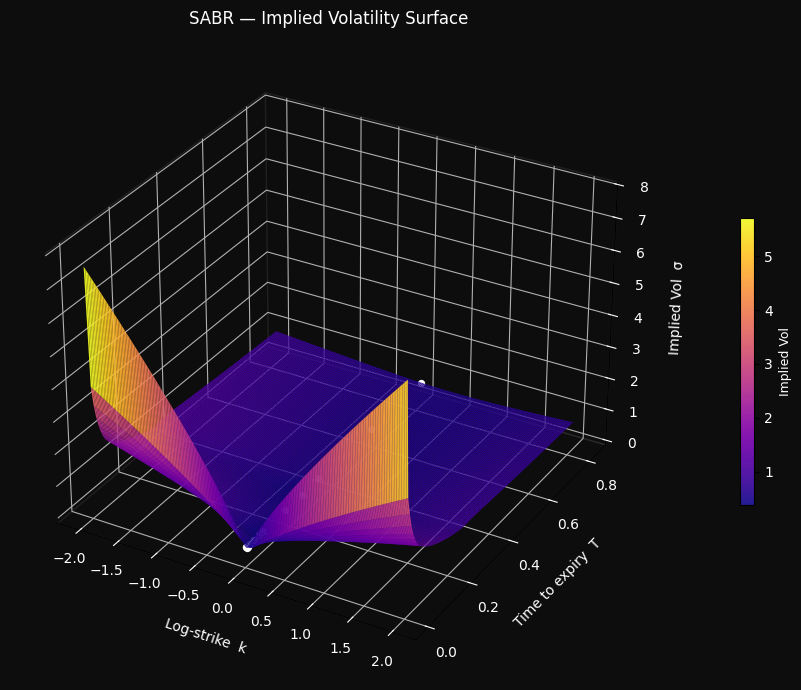

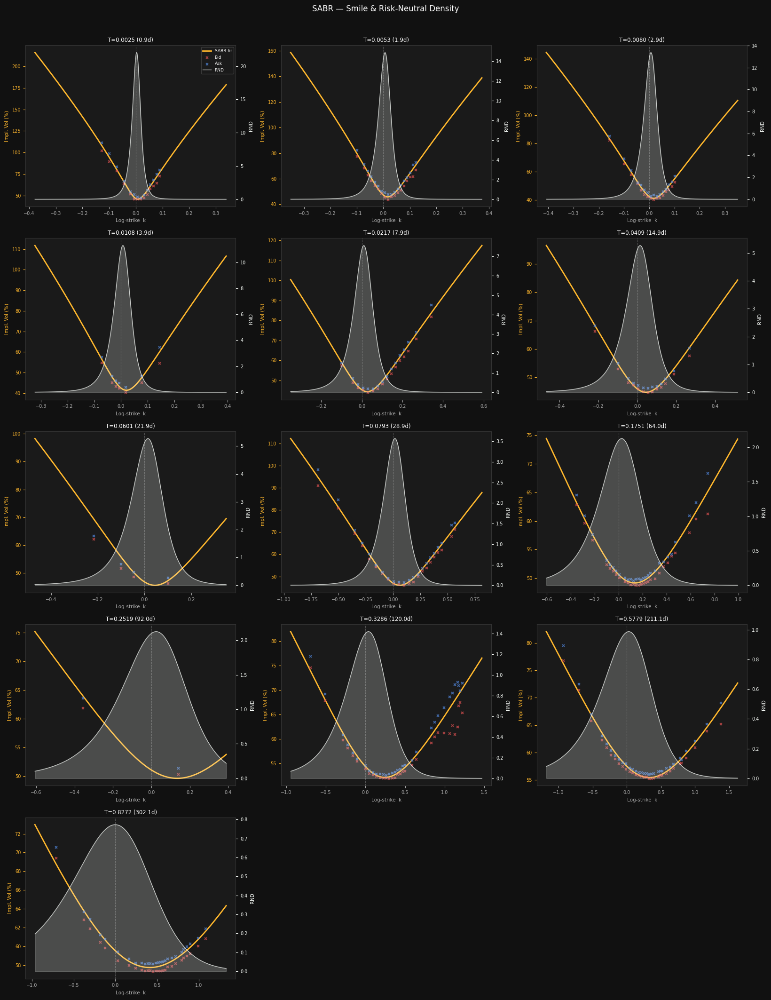

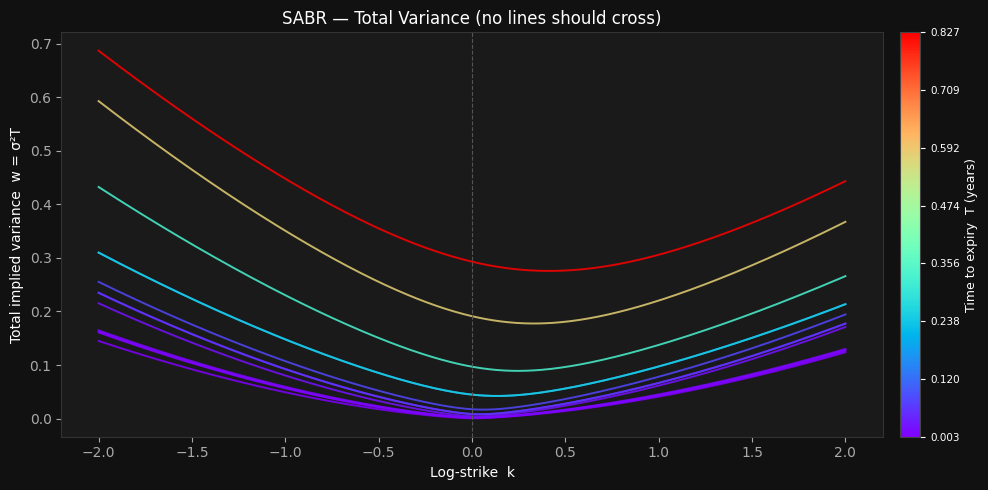

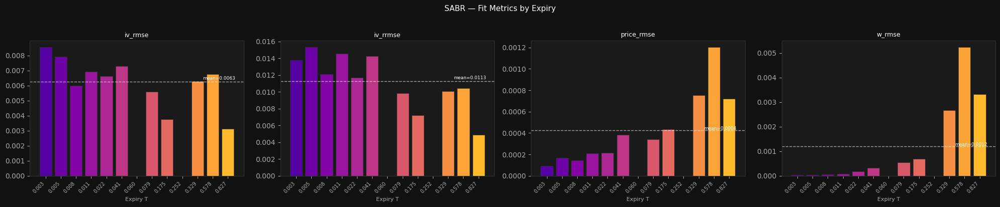

In [35]:
plot_all(dict_results['sabr_iv_rmse'], df=snapshot);

## Vega Weighted MSE

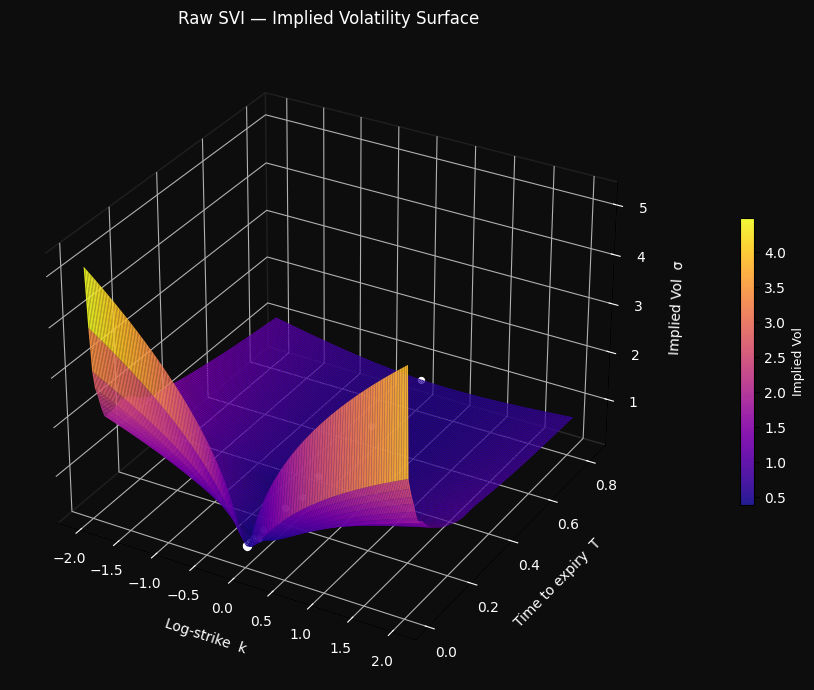

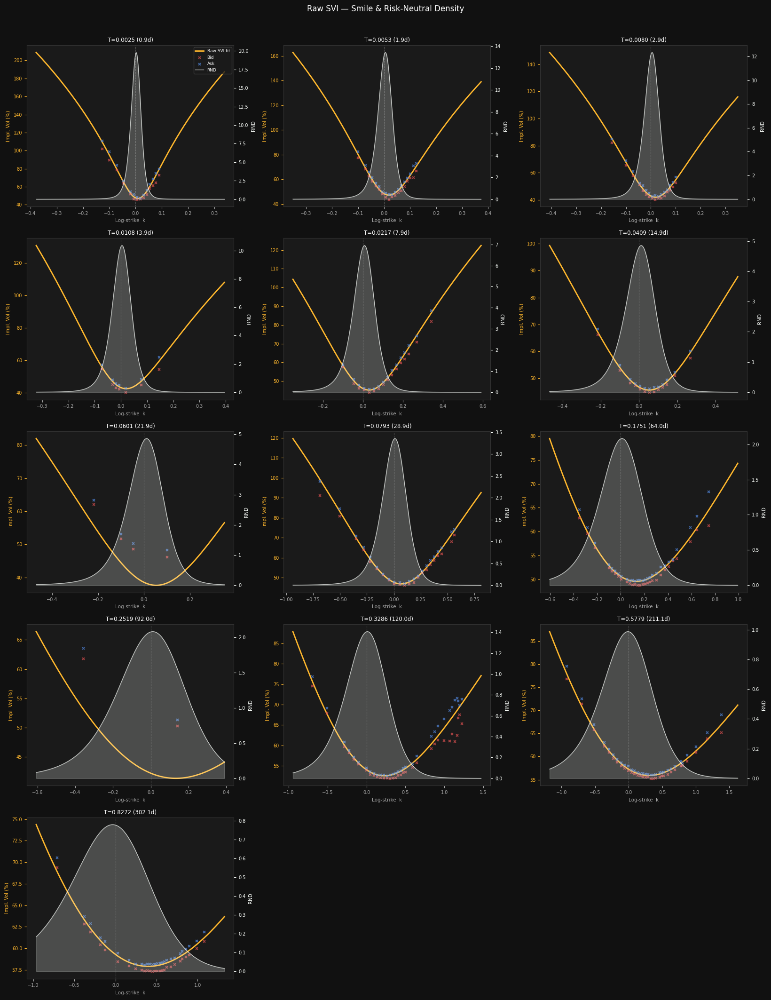

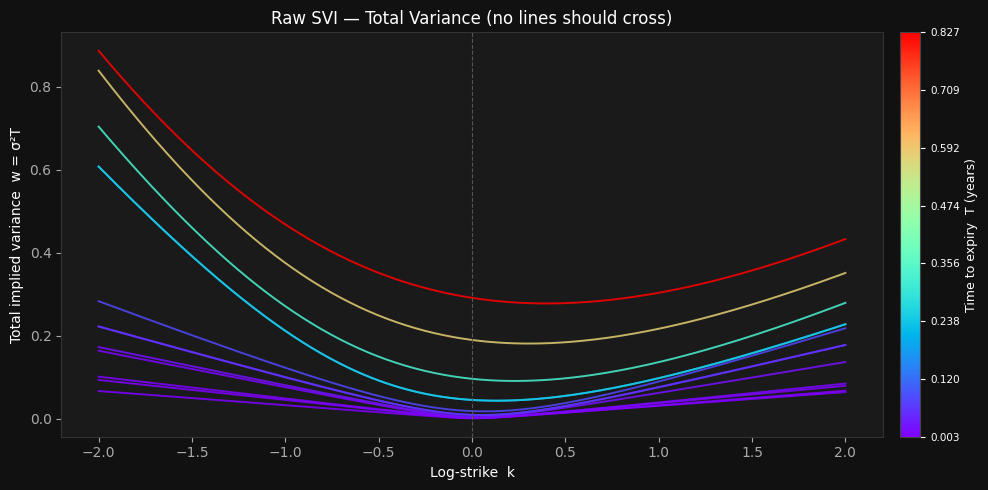

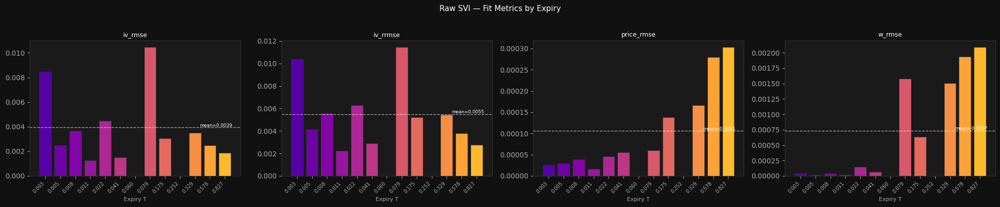

In [36]:
plot_all(dict_results['svi_vega_wmse'], df=snapshot);

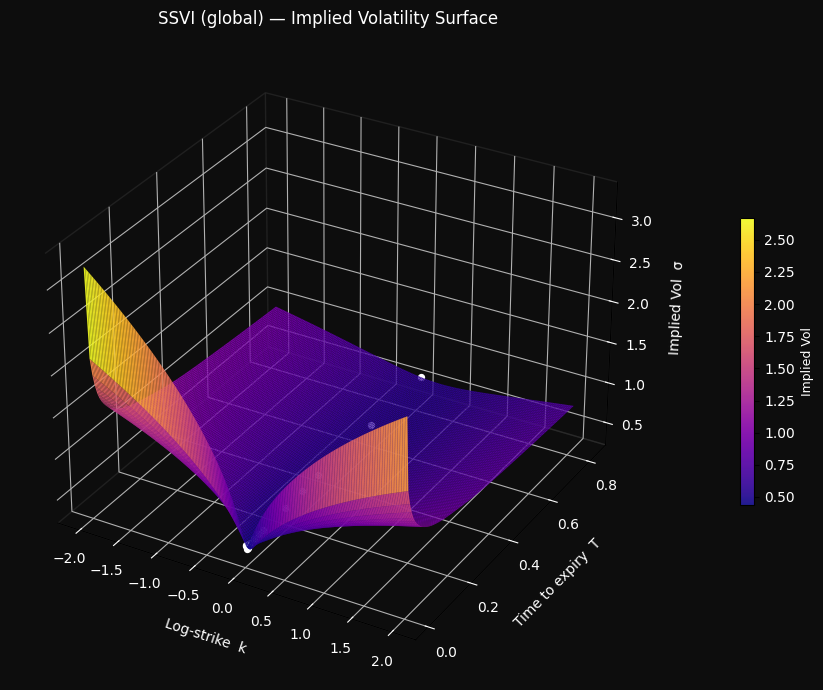

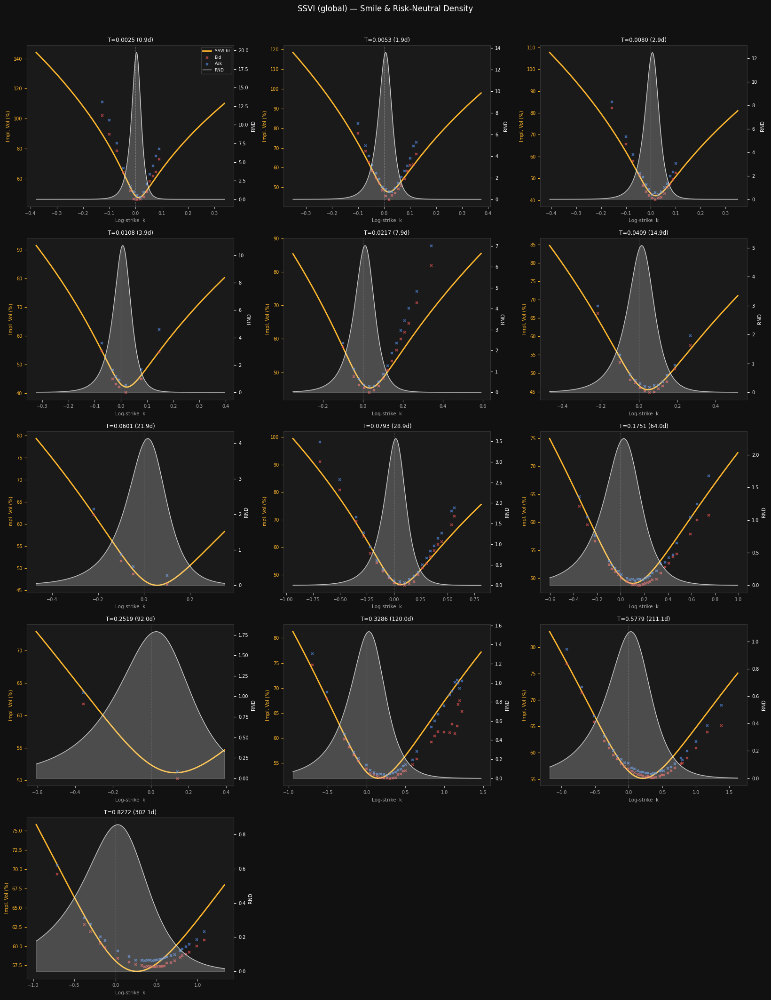

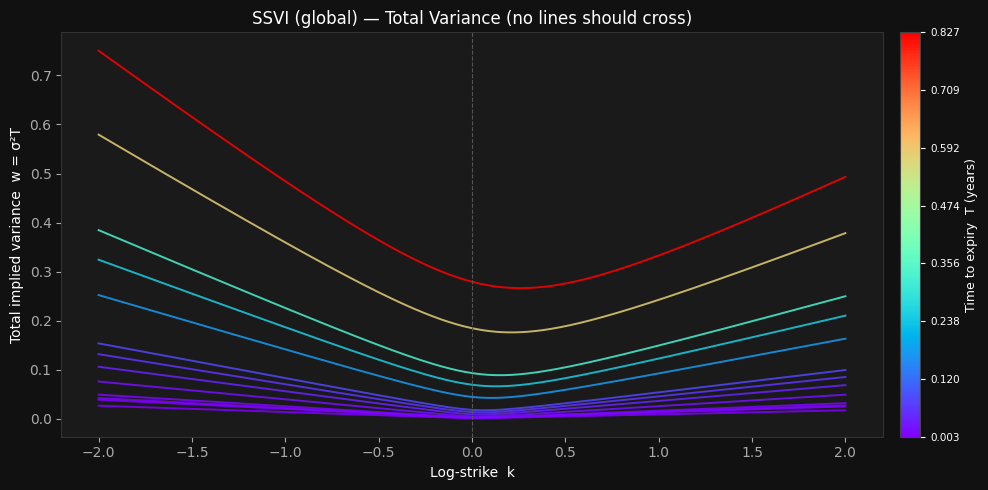

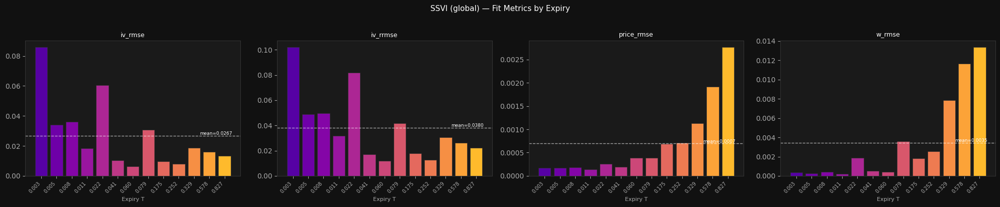

In [37]:
plot_all(dict_results['ssvi_vega_wmse'], df=snapshot);

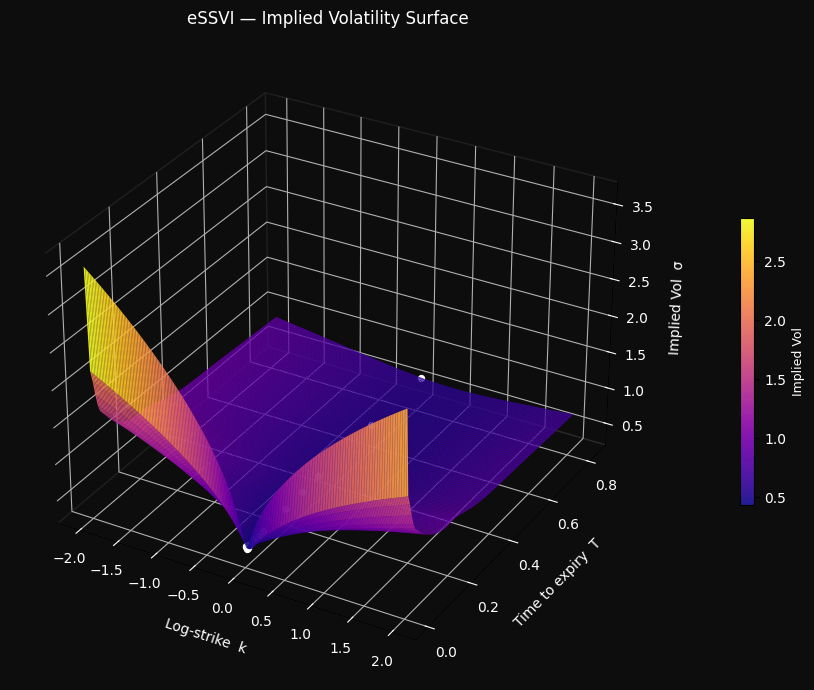

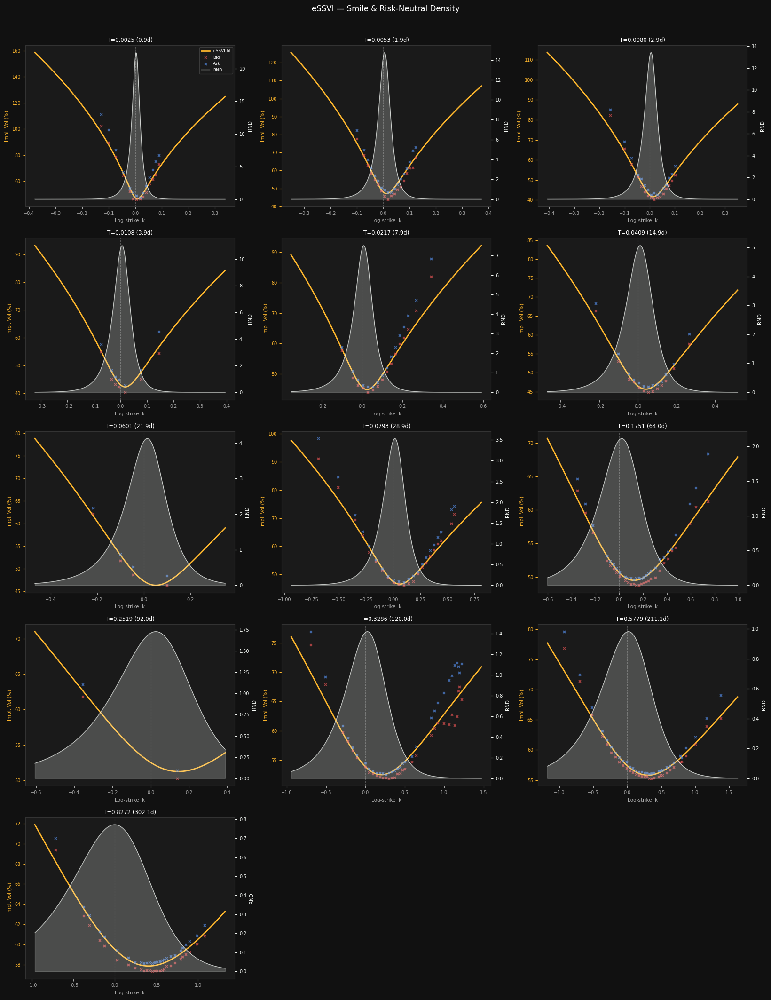

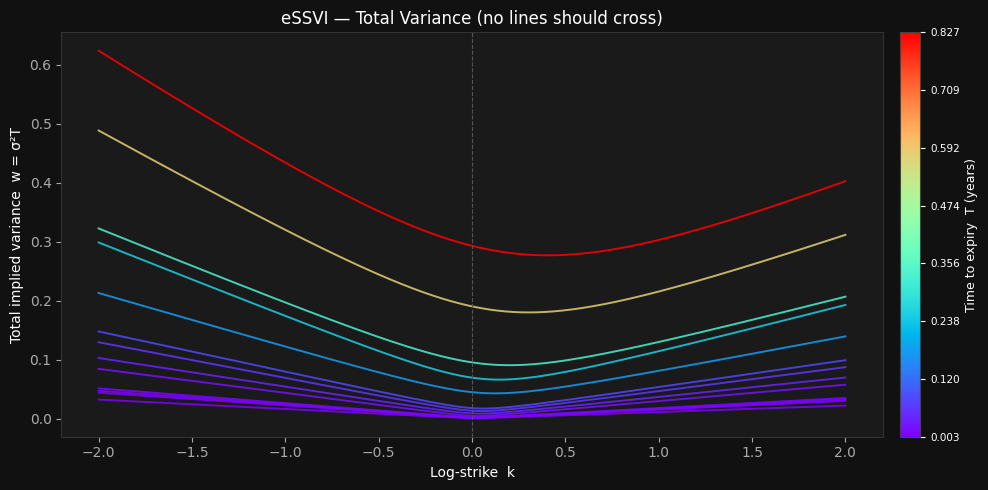

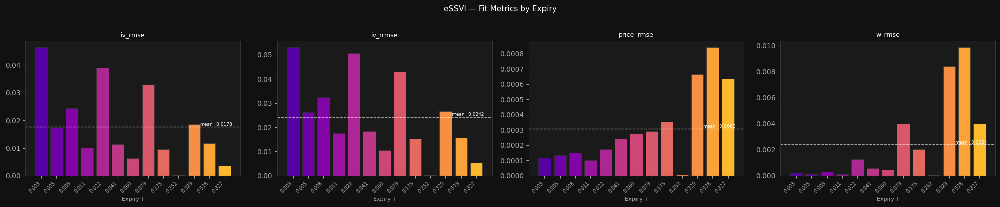

In [38]:
plot_all(dict_results['essvi_vega_wmse'], df=snapshot);

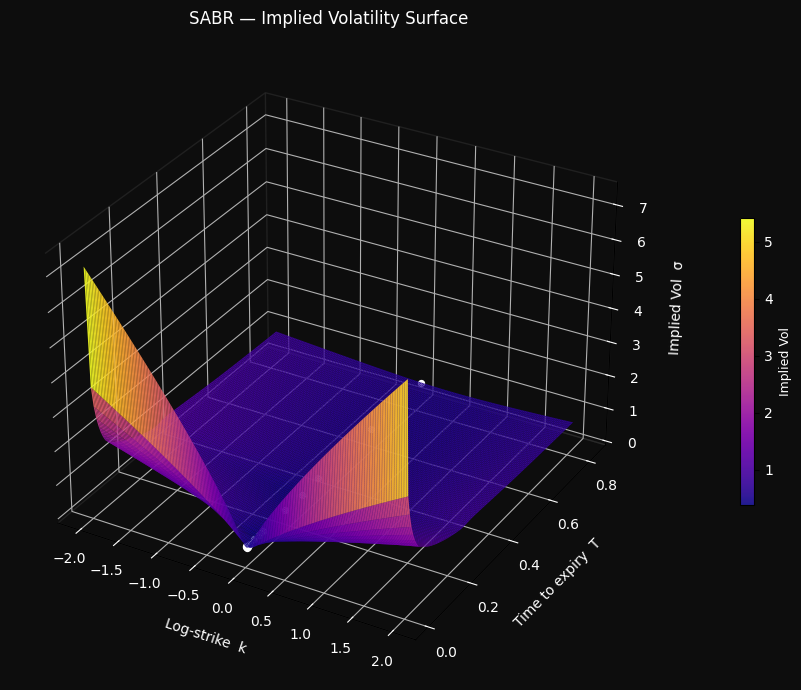

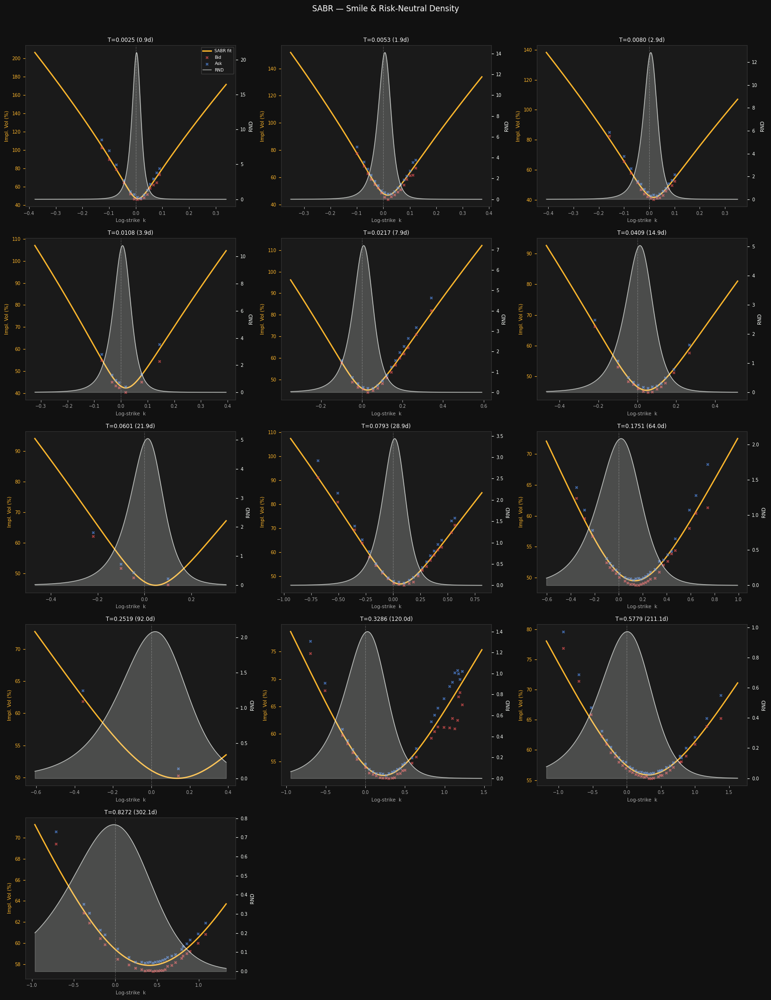

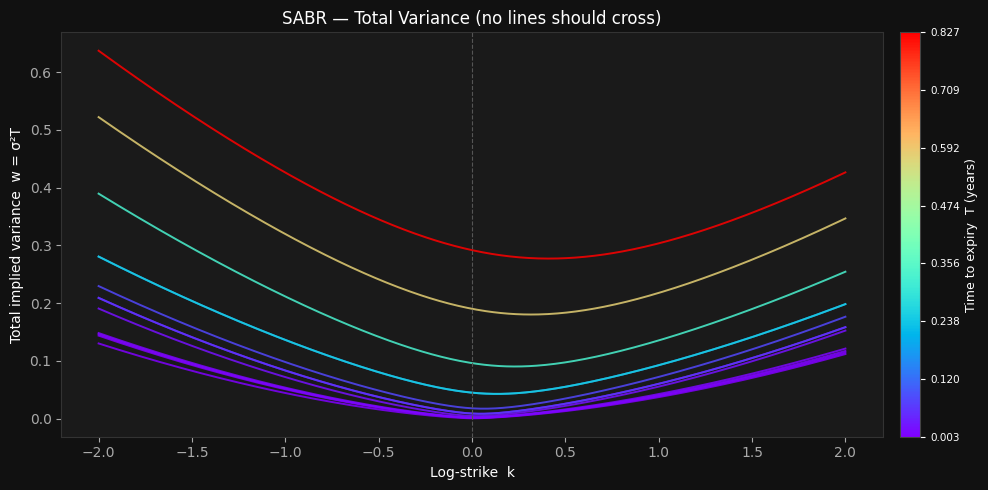

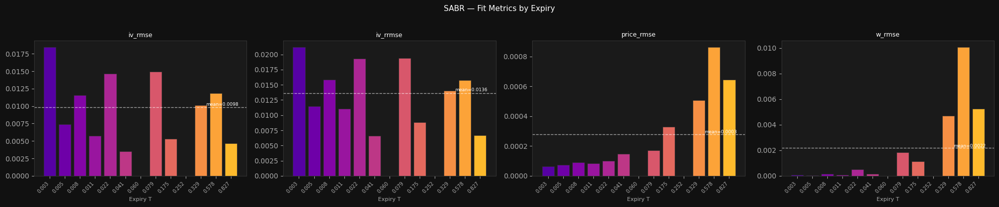

In [39]:
plot_all(dict_results['sabr_vega_wmse'], df=snapshot);

In [ ]:
import pickle
with open('calibration_results/dict_results.pkl','rb') as f:
    dict_results = pickle.load(f)

In [ ]:

from volatility_surface.models.vol_models import get_model
# After calibrating

# Quantitative check
diag = check_arbitrage(result, n_strikes=500, n_times=200)
print(diag["summary"])
if not diag["calendar_free"]:
    print(f"Calendar arb at (k={diag['calendar_worst_k']:.3f}, "
          f"t={diag['calendar_worst_t']:.4f}), worst ∂w/∂t = {diag['calendar_worst']:.2e}")

# Visual diagnostic
plot_arbitrage_map(result)

In [8]:
dict_results.keys()

dict_keys(['svi_iv_rmse', 'svi_vega_wmse', 'ssvi_iv_rmse', 'ssvi_vega_wmse', 'essvi_iv_rmse', 'essvi_vega_wmse', 'sabr_iv_rmse', 'sabr_vega_wmse'])

In [8]:
from arbitrage_checker import check_arbitrage, plot_arbitrage_map
diag = check_arbitrage(init_surf, n_strikes=500, n_times=400)
print(diag['summary'])


──────────────────────────────────────────────────────────────────────────────
  Static-arbitrage check — SABR
  Grid: 500 strikes × 400 maturities   (k ∈ [-2, 2],  t ∈ [0.0021, 0.8131])
  FD steps: dk=0.001  dt=0.0005     tolerance=1e-06
──────────────────────────────────────────────────────────────────────────────
  Calendar  [FAIL]  worst ∂w/∂t = -4.165e-02  @ (k=-2.000, t=0.0021)  violations: 0.022% of grid
  Butterfly [PASS]  worst g      = +1.406e-02  @ (k=+2.000, t=0.0102)  violations: 0.000% of grid
──────────────────────────────────────────────────────────────────────────────


In [ ]:
from volatility_surface.models.vol_models import get_model 
from objectives import get_objective
from time import time
df1 = clean_df('/Users/macbookair/Internship Natixis/data/market_making/eth_2026-06-02_15-27-21.csv')
df2 = clean_df('/Users/macbookair/Internship Natixis/data/market_making/eth_2026-06-02_15-27-22.csv')

t1 = time()
init_surf = calibrate_snapshot(df1, model=get_model('sabr'), objective=get_objective('vega_wmse'), verbose=False, penalty_cal=0)
t2 = time()
updated_surf_full_polish = calibrate_global_essvi_update(df2, init_surf, model = get_model('sabr'), objective=get_objective('vega_wmse'), mode='full_polish', verbose=False)
t3 = time()
update_surf_theta = calibrate_global_essvi_update(df2, init_surf, model = get_model('sabr'), objective=get_objective('vega_wmse'), mode='theta_only', verbose=False)
t4 = time()

print(f'Initial calibration of essvi takes {round(t2-t1,2)}s')
print(f'Full polish update of essvi takes {round(t3-t2,2)}s')
print(f'Theta only update of essvi takes {round(t4-t3,2)}s')

KeyError: 't'

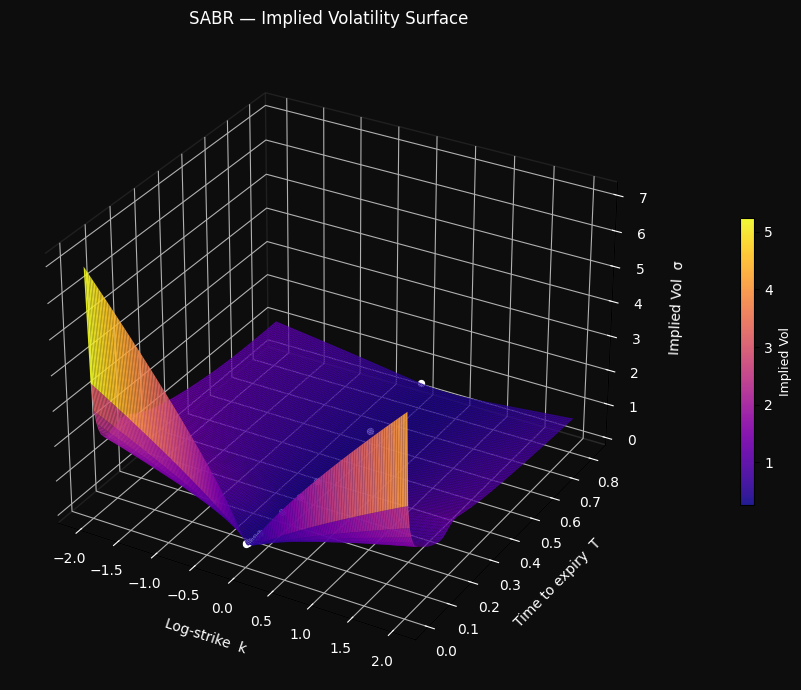

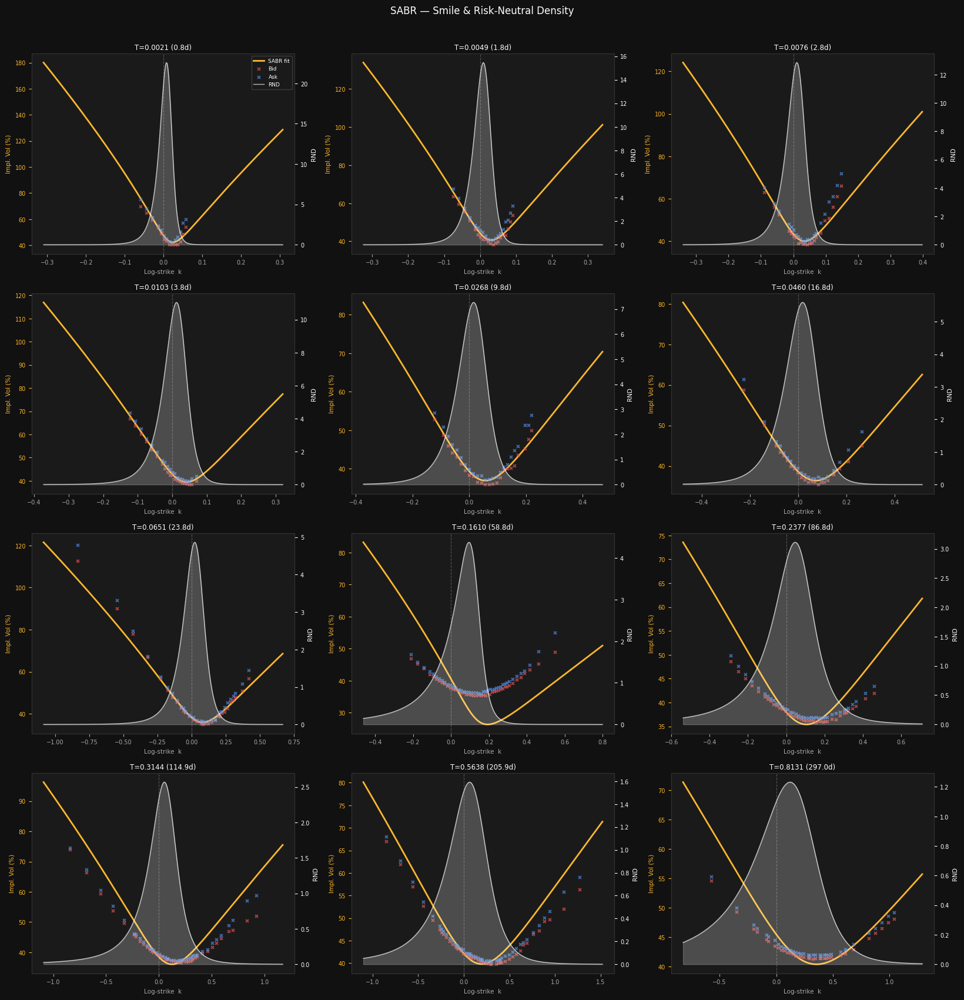

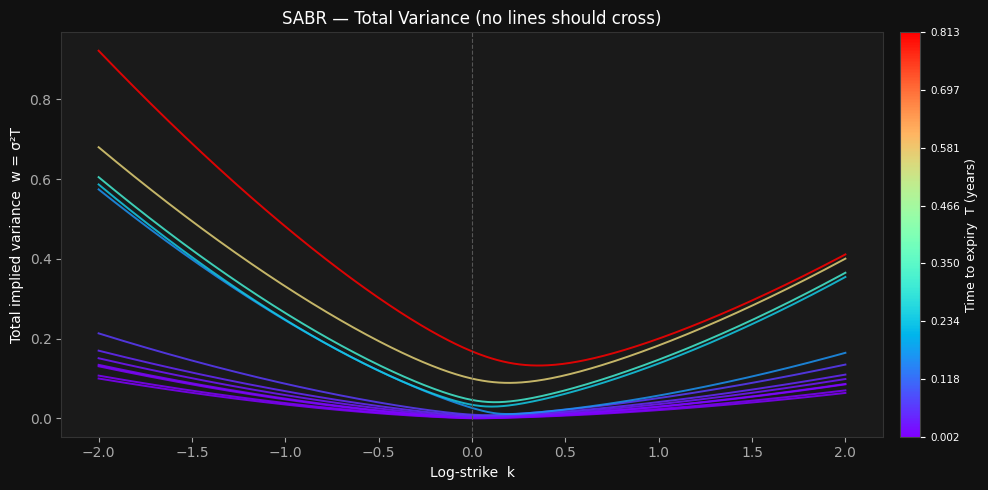

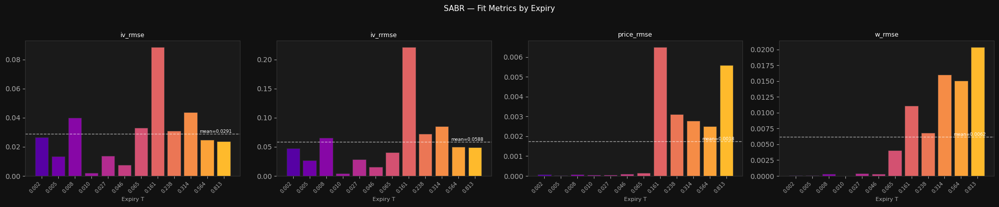

In [28]:
plot_all(init_surf, df=df1);

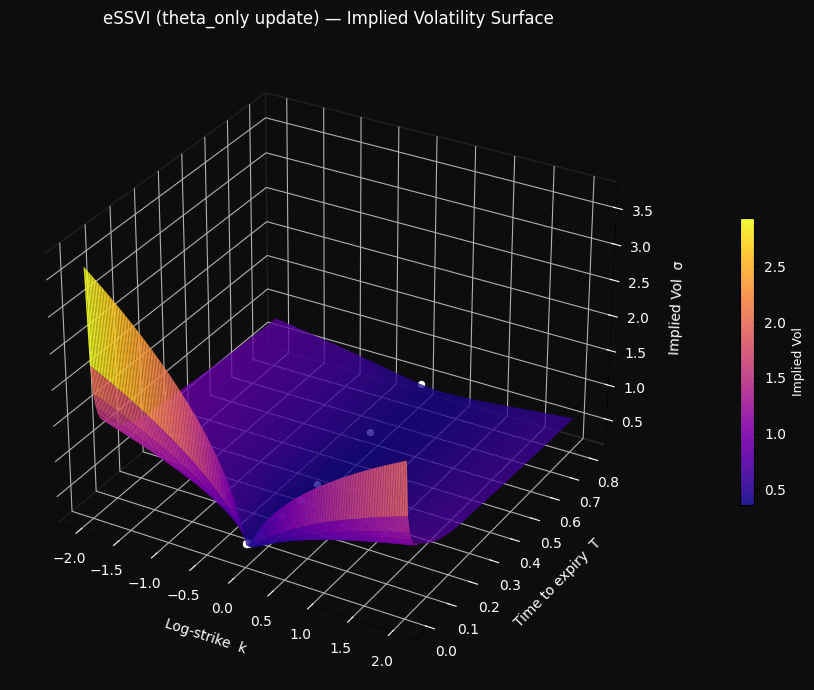

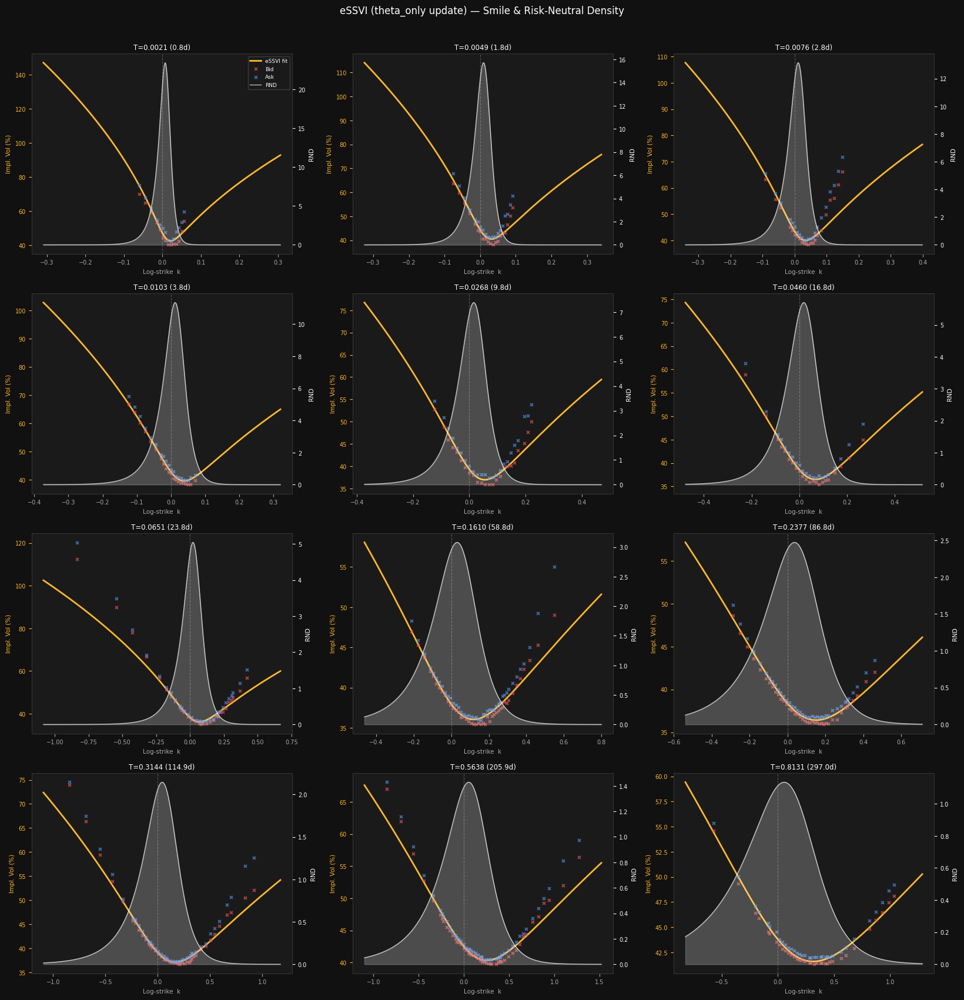

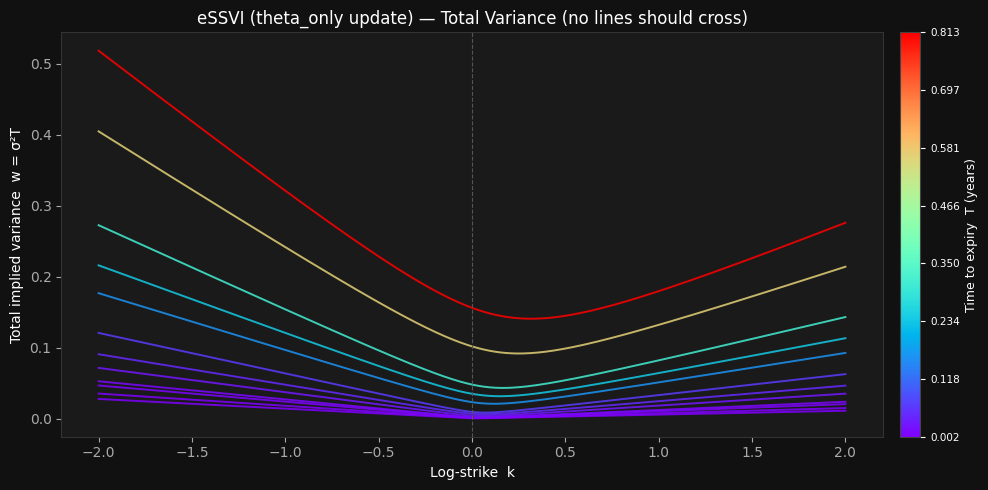

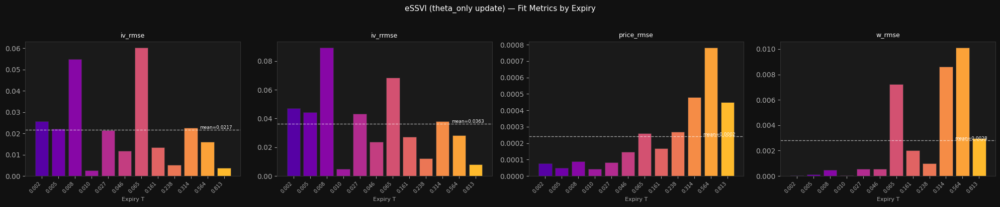

In [19]:
plot_all(update_surf_theta, df=df2);

(<Figure size 1200x700 with 2 Axes>,
 <Figure size 1650x1680 with 24 Axes>,
 <Figure size 1000x500 with 2 Axes>,
 <Figure size 2000x400 with 4 Axes>)

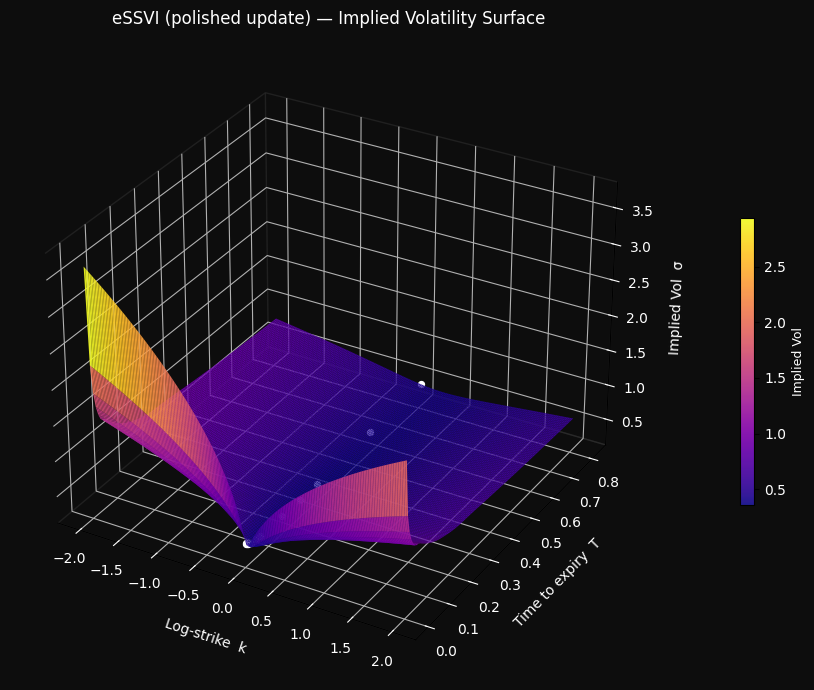

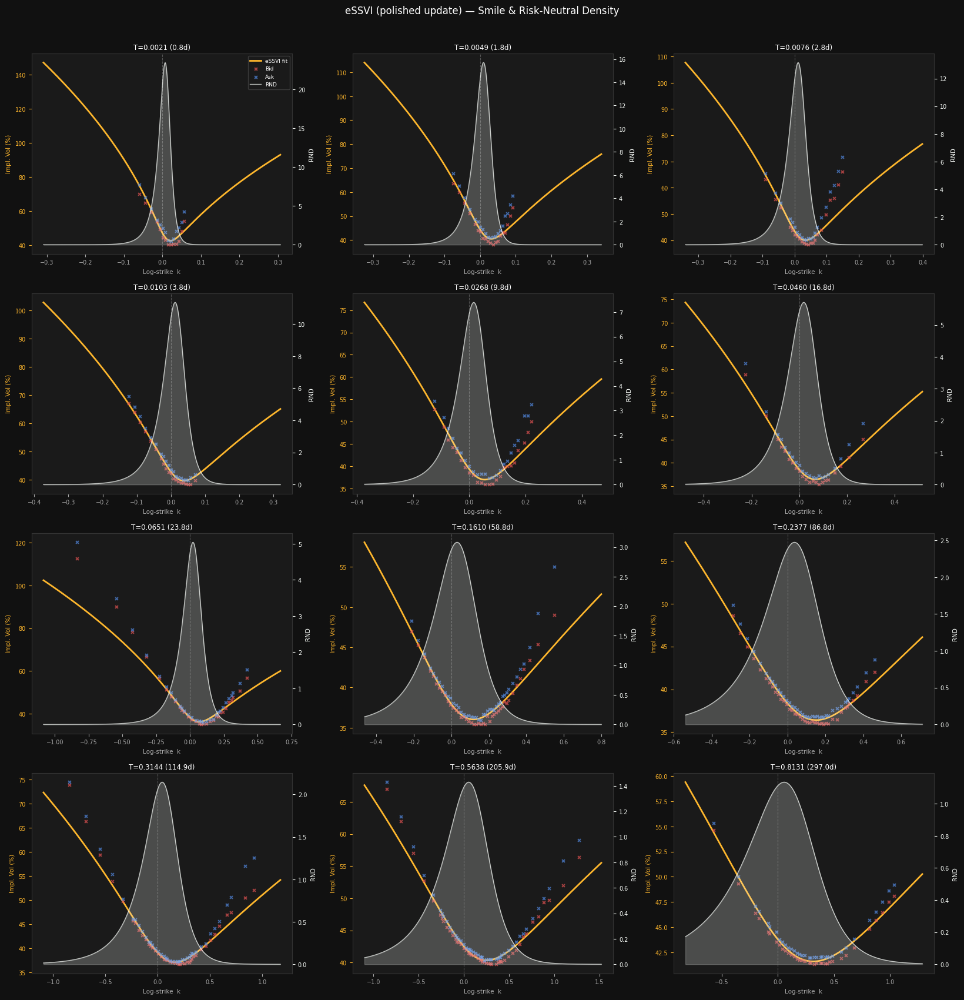

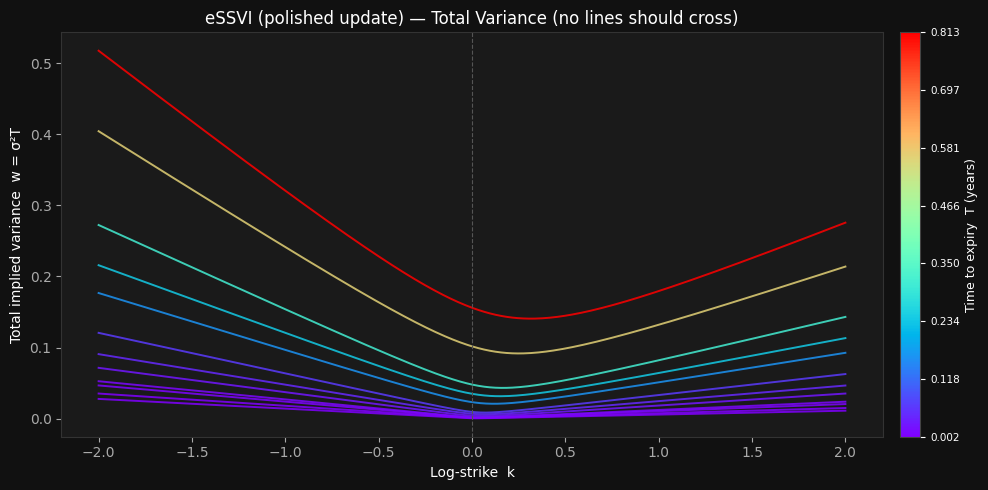

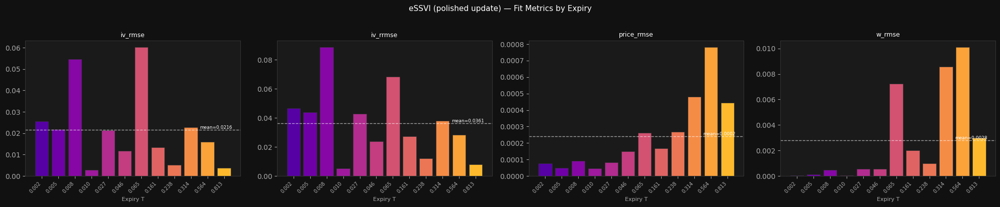

In [20]:
plot_all(updated_surf_full_polish, df=df2);

In [32]:
init_surf = calibrate_snapshot(df1, model=get_model('sabr'), objective=get_objective('vega_wmse'), verbose=False, penalty_cal=0)


(<Figure size 1200x700 with 2 Axes>,
 <Figure size 1650x1680 with 24 Axes>,
 <Figure size 1000x500 with 2 Axes>,
 <Figure size 2000x400 with 4 Axes>)

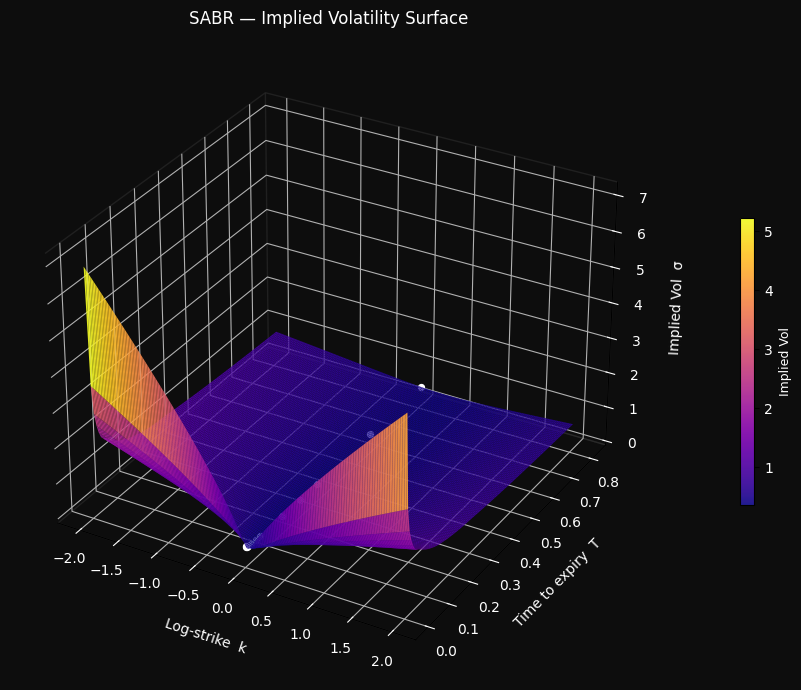

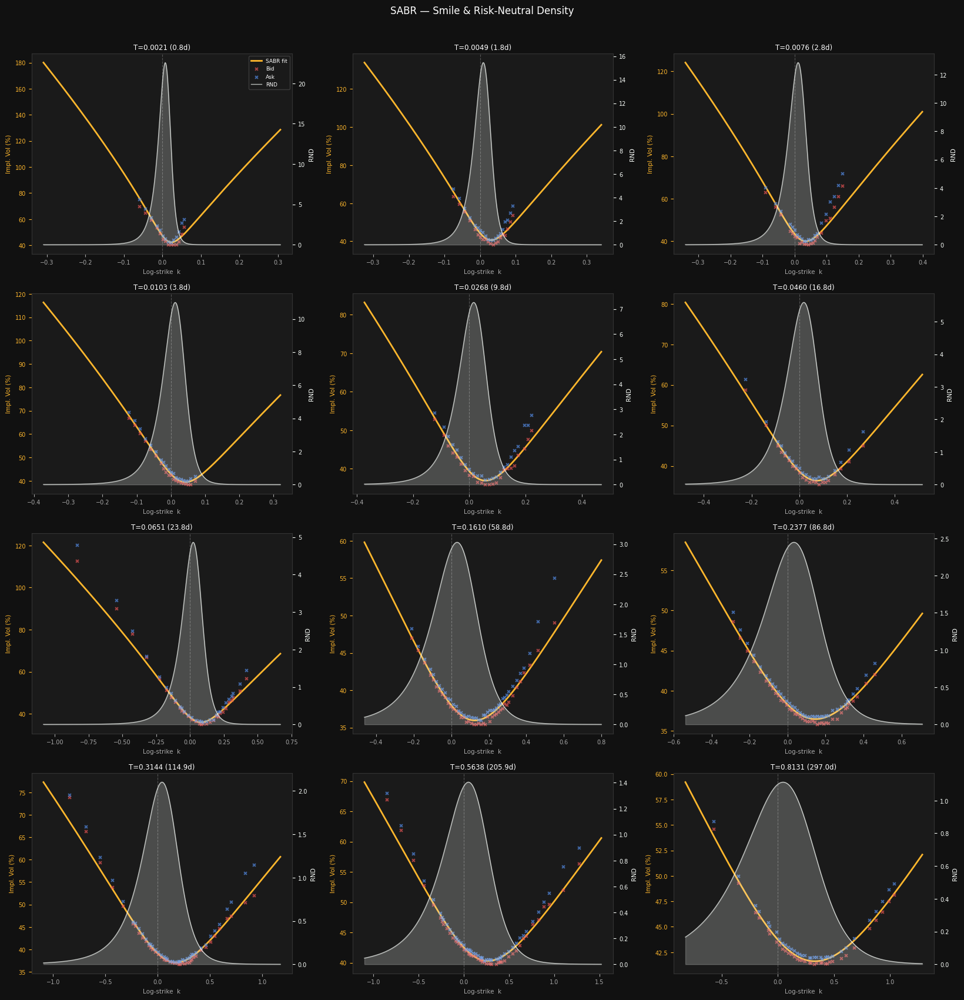

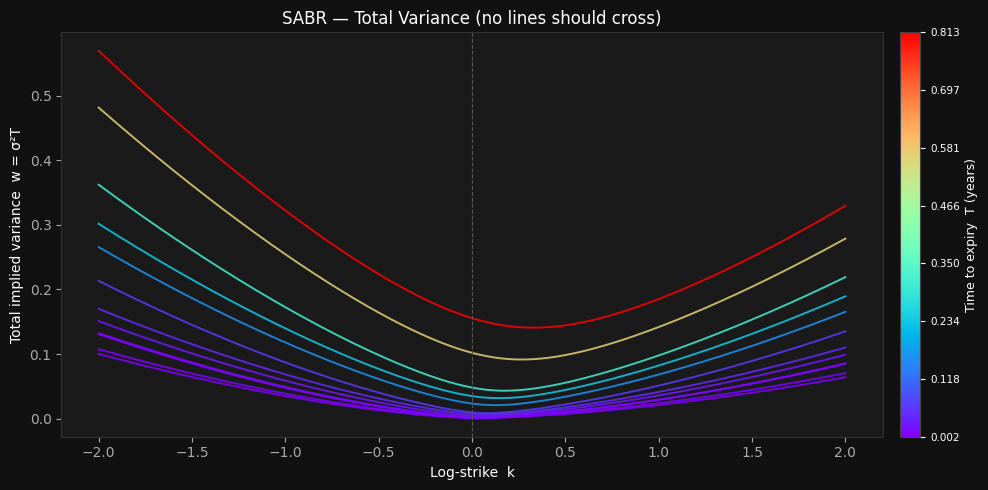

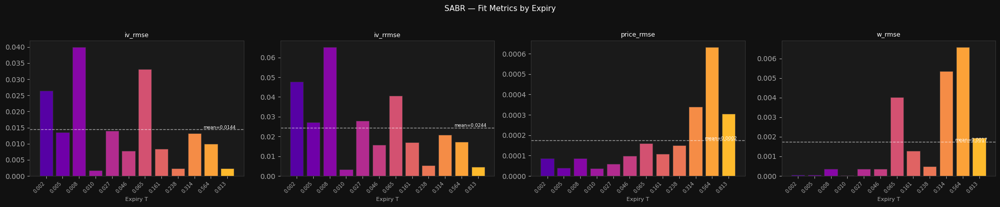

In [33]:
plot_all(init_surf,df=df1);

In [ ]:
from volatility_surface.models.vol_models import get_model
from objectives import get_objective 
from calibrator import calibrate_snapshot
init_surf = calibrate_snapshot(df1, model=get_model('af_sabr'), objective=get_objective('vega_wmse'))
plot_all(init_surf)


Model     : Arb-Free SABR
Objective : obj_iv_vega_wmse
Slices    : 12

  [1/12] T=0.0021  n= 14  cal=0.0e+00  [ok]  iv_rmse=0.0917  iv_rrmse=0.1753  price_rmse=0.0002  w_rmse=0.0002
  [2/12] T=0.0049  n= 20  cal=0.0e+00  [ok]  iv_rmse=0.0912  iv_rrmse=0.1857  price_rmse=0.0002  w_rmse=0.0004
  [3/12] T=0.0076  n= 22  cal=0.0e+00  [ok]  iv_rmse=0.1087  iv_rrmse=0.2466  price_rmse=0.0025  w_rmse=0.0008
  [4/12] T=0.0103  n= 20  cal=0.0e+00  [ok]  iv_rmse=0.0757  iv_rrmse=0.1445  price_rmse=0.0014  w_rmse=0.0008


KeyboardInterrupt: 

# LOOK AT WHY VEGA WMSE PERFORMS SO MUCH WORSE THAN IV RMSE ON SABR


Model     : SABR
Objective : obj_iv_vega_wmse
Slices    : 12

  [1/12] T=0.0021  n= 14  cal=0.0e+00  [ok]  iv_rmse=0.0264  iv_rrmse=0.0477  price_rmse=0.0001  w_rmse=0.0001
  [2/12] T=0.0049  n= 20  cal=0.0e+00  [ok]  iv_rmse=0.0135  iv_rrmse=0.0271  price_rmse=0.0000  w_rmse=0.0001
  [3/12] T=0.0076  n= 22  cal=0.0e+00  [ok]  iv_rmse=0.0399  iv_rrmse=0.0652  price_rmse=0.0001  w_rmse=0.0004
  [4/12] T=0.0103  n= 20  cal=0.0e+00  [ok]  iv_rmse=0.4951  iv_rrmse=0.9251  price_rmse=0.0150  w_rmse=0.0093
  [5/12] T=0.0268  n= 24  cal=0.0e+00  [ok]  iv_rmse=0.1800  iv_rrmse=0.3882  price_rmse=0.0084  w_rmse=0.0061
  [6/12] T=0.0460  n= 22  cal=0.0e+00  [ok]  iv_rmse=0.1353  iv_rrmse=0.2796  price_rmse=0.0069  w_rmse=0.0081
  [7/12] T=0.0651  n= 30  cal=0.0e+00  [ok]  iv_rmse=0.1961  iv_rrmse=0.2764  price_rmse=0.0055  w_rmse=0.0283
  [8/12] T=0.1610  n= 43  cal=0.0e+00  [ok]  iv_rmse=0.7635  iv_rrmse=1.9617  price_rmse=0.1061  w_rmse=0.2017
  [9/12] T=0.2377  n= 40  cal=0.0e+00  [ok]  iv_r

(<Figure size 1200x700 with 2 Axes>,
 <Figure size 1650x1680 with 24 Axes>,
 <Figure size 1000x500 with 2 Axes>,
 <Figure size 2000x400 with 4 Axes>)

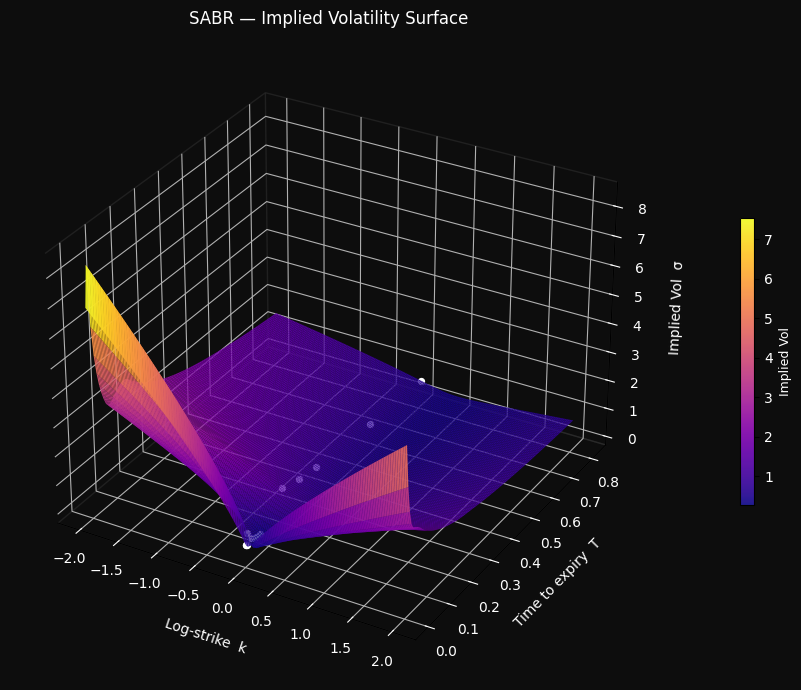

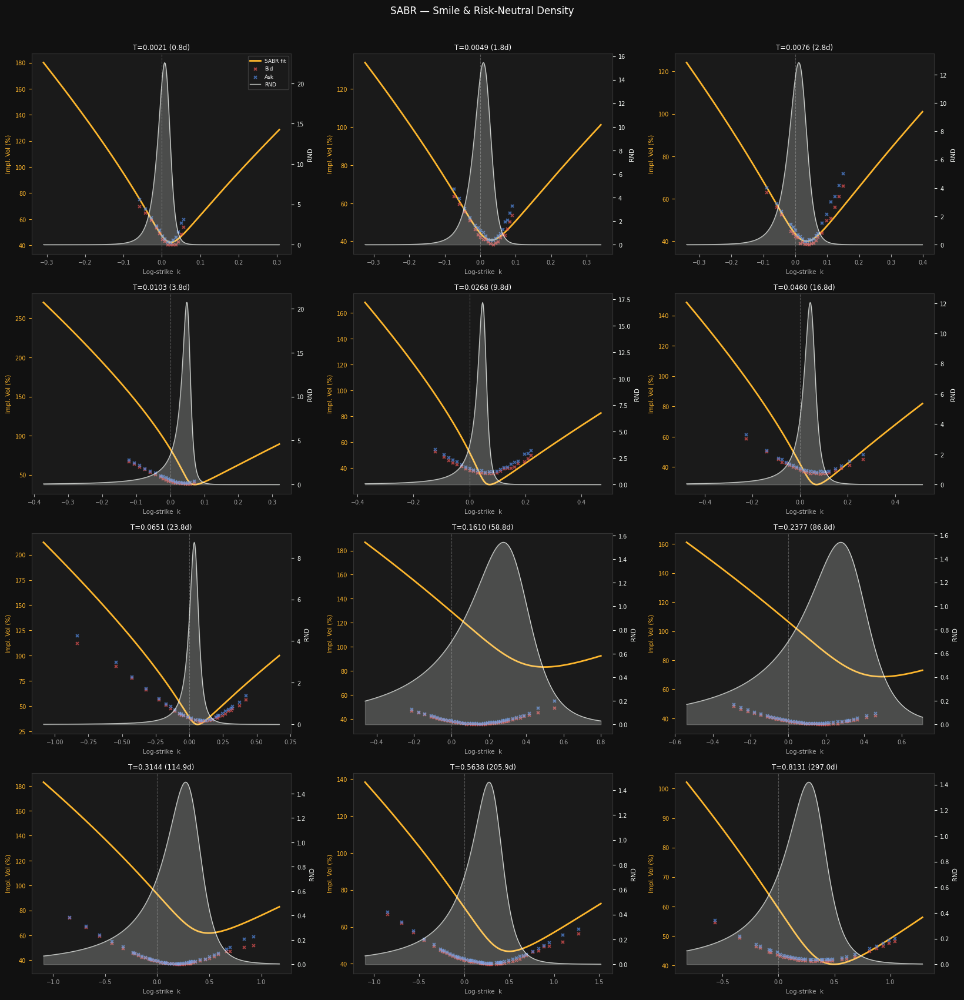

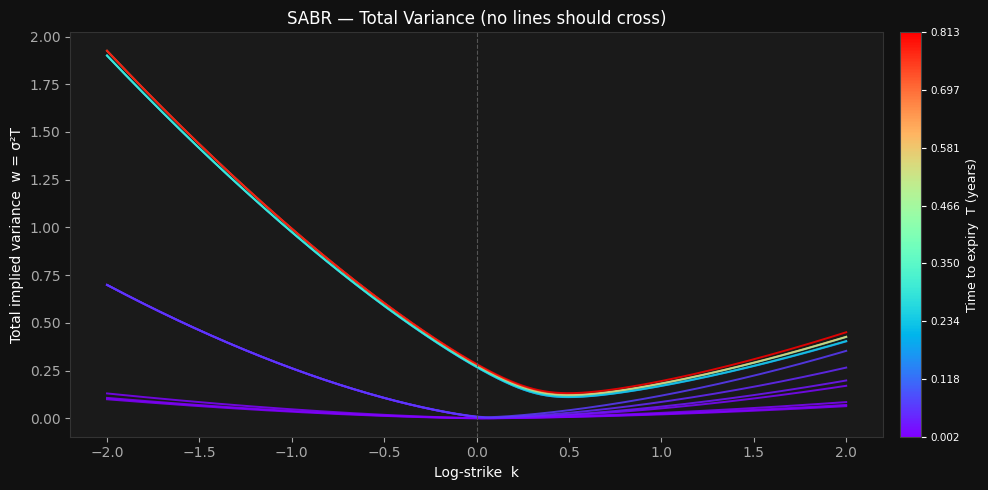

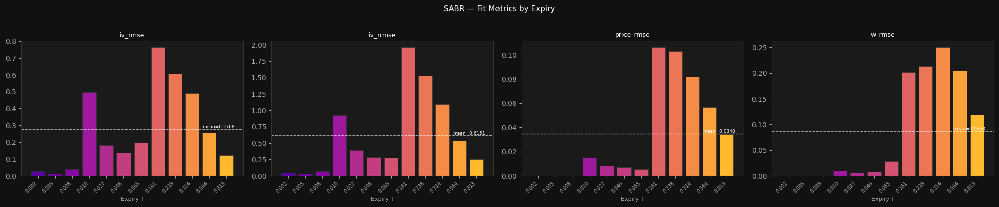

In [7]:

init_surf = calibrate_snapshot(
    df1,
    model     = get_model('sabr'),
    objective = get_objective('vega_wmse'),
    use_global_init = False,      # ← critical: skips differential evolution
)
plot_all(init_surf, df=df1)

In [25]:
# One-shot
df1 = clean_df('/Users/macbookair/Internship Natixis/data/market_making/eth_2026-06-02_15-27-21.csv')

result_no_arb_cond = calibrate_snapshot(df1, model=get_model("sabr"), objective=get_objective('iv_rmse'))
result_arb_cond = calibrate_snapshot(df1, model=get_model('sabr'), objective=get_objective('iv_rmse'), enforce_arbfree=True)
# Or post-hoc on any existing per-slice SABR result
from calibrator import enforce_calendar_arbfree
result = enforce_calendar_arbfree(result_no_arb_cond, df1)


Model     : SABR
Objective : obj_iv_rmse
Slices    : 12

  [1/12] T=0.0021  n= 14  cal=0.0e+00  [ok]  iv_rmse=0.0166  iv_rrmse=0.0323  price_rmse=0.0002  w_rmse=0.0000
  [2/12] T=0.0049  n= 20  cal=0.0e+00  [ok]  iv_rmse=0.0072  iv_rrmse=0.0158  price_rmse=0.0001  w_rmse=0.0000
  [3/12] T=0.0076  n= 22  cal=0.0e+00  [ok]  iv_rmse=0.0198  iv_rrmse=0.0413  price_rmse=0.0003  w_rmse=0.0002
  [4/12] T=0.0103  n= 20  cal=0.0e+00  [ok]  iv_rmse=0.0139  iv_rrmse=0.0296  price_rmse=0.0003  w_rmse=0.0001
  [5/12] T=0.0268  n= 24  cal=0.0e+00  [ok]  iv_rmse=0.0087  iv_rrmse=0.0206  price_rmse=0.0003  w_rmse=0.0002
  [6/12] T=0.0460  n= 22  cal=0.0e+00  [ok]  iv_rmse=0.0044  iv_rrmse=0.0110  price_rmse=0.0002  w_rmse=0.0002
  [7/12] T=0.0651  n= 30  cal=0.0e+00  [ok]  iv_rmse=0.0121  iv_rrmse=0.0255  price_rmse=0.0006  w_rmse=0.0010
  [8/12] T=0.1610  n= 43  cal=0.0e+00  [ok]  iv_rmse=0.0057  iv_rrmse=0.0129  price_rmse=0.0004  w_rmse=0.0008
  [9/12] T=0.2377  n= 40  cal=0.0e+00  [ok]  iv_rmse=0

In [4]:
from arbitrage_checker import check_arbitrage, plot_arbitrage_map
diag = check_arbitrage(result_no_arb_cond, n_strikes=500, n_times=400)
print(diag['summary'])


──────────────────────────────────────────────────────────────────────────────
  Static-arbitrage check — SABR
  Grid: 500 strikes × 400 maturities   (k ∈ [-2, 2],  t ∈ [0.0021, 0.8131])
  FD steps: dk=0.001  dt=0.0005     tolerance=1e-06
──────────────────────────────────────────────────────────────────────────────
  Calendar  [PASS]  worst ∂w/∂t = +2.606e-04  @ (k=-2.000, t=0.8131)  violations: 0.000% of grid
  Butterfly [PASS]  worst g      = +3.152e-02  @ (k=+2.000, t=0.0021)  violations: 0.000% of grid
──────────────────────────────────────────────────────────────────────────────


In [13]:
if diag['calendar_free']==True:
    print('okay')

okay


In [13]:
csv_files = sorted(glob.glob(f'data/eth/*.csv'))
arbitrageable = []
no_arb_dict = {}
for file in csv_files:
    df1 = clean_df(f'/Users/macbookair/Internship Natixis/{file}')

    result_no_arb_cond = calibrate_snapshot(df1, model=get_model("sabr"), objective=get_objective('iv_rmse'), verbose=False)
    
    diag = check_arbitrage(result_no_arb_cond, n_strikes=500, n_times=400)
    if diag['calendar_free'] and diag['butterfly_free']:
        print(f' {file} is Arbitrage free')
    else:
        result_arb_cond = calibrate_snapshot(df1, model=get_model("sabr"), objective=get_objective('iv_rmse'), enforce_arbfree=True,verbose=False)
        second_diag =check_arbitrage(result_arb_cond, n_strikes=500, n_times=400)
        if second_diag['calendar_free'] and second_diag['butterfly_free']:
            print(f'/_\ {file} is  Arbitrage free after arb enforcement')
        else:
            print(f'-- {file} is not arbitrage free : cal {second_diag['calendar_free']}, butterfly: {second_diag['butterfly_free']}')

-- data/eth/eth_2026-06-04_22-06.csv is not arbitrage free : cal True, butterfly: False
 data/eth/eth_2026-06-05_09-50.csv is Arbitrage free
 data/eth/eth_option_data_2026-05-21_15h41m.csv is Arbitrage free
-- data/eth/eth_option_data_2026-05-21_15h42m.csv is not arbitrage free : cal False, butterfly: True
 data/eth/eth_option_data_2026-05-21_15h43m.csv is Arbitrage free
-- data/eth/eth_option_data_2026-05-21_15h44m.csv is not arbitrage free : cal False, butterfly: True
-- data/eth/eth_option_data_2026-05-21_15h45m.csv is not arbitrage free : cal False, butterfly: True
 data/eth/eth_option_data_2026-05-22_16h42m.csv is Arbitrage free
 data/eth/eth_option_data_2026-05-27_13h26m.csv is Arbitrage free
 data/eth/eth_option_data_2026-05-27_13h43m.csv is Arbitrage free
 data/eth/eth_option_data_2026-05-28_11h42m.csv is Arbitrage free
 data/eth/eth_option_data_2026-06-02_09h26m.csv is Arbitrage free


In [17]:
df_test = clean_df('data/eth/eth_option_data_2026-05-21_15h42m.csv')
res = calibrate_snapshot(df_test, model=get_model('sabr'), objective=get_objective('vega_wmse'), enforce_arbfree=True, verbose=False)
res_arb = calibrate_snapshot(df_test, model=get_model('sabr'), objective=get_objective('vega_wmse'), verbose=False)
check_arbitrage(res), check_arbitrage(res_arb)

({'calendar_free': True,
  'butterfly_free': True,
  'calendar_worst': 0.08344127820048164,
  'calendar_worst_k': -0.004008016032064354,
  'calendar_worst_t': 0.006329229963076418,
  'calendar_violation_pct': 0.0,
  'butterfly_worst': 0.03175549210158685,
  'butterfly_worst_k': 2.0,
  'butterfly_worst_t': 0.0020888499809741247,
  'butterfly_violation_pct': 0.0,
  'summary': '──────────────────────────────────────────────────────────────────────────────\n  Static-arbitrage check — SABR\n  Grid: 500 strikes × 200 maturities   (k ∈ [-2, 2],  t ∈ [0.0021, 0.8459])\n  FD steps: dk=0.001  dt=0.0005     tolerance=1e-06\n──────────────────────────────────────────────────────────────────────────────\n  Calendar  [PASS]  worst ∂w/∂t = +8.344e-02  @ (k=-0.004, t=0.0063)  violations: 0.000% of grid\n  Butterfly [PASS]  worst g      = +3.176e-02  @ (k=+2.000, t=0.0021)  violations: 0.000% of grid\n──────────────────────────────────────────────────────────────────────────────'},
 {'calendar_free': T

In [18]:
df_test = clean_df('data/eth/eth_option_data_2026-05-21_15h42m.csv')
res = calibrate_snapshot(df_test, model=get_model('sabr'), objective=get_objective('iv_rmse'), enforce_arbfree=True, verbose=False)
res_arb = calibrate_snapshot(df_test, model=get_model('sabr'), objective=get_objective('iv_rmse'), verbose=False)
check_arbitrage(res), check_arbitrage(res_arb)

({'calendar_free': True,
  'butterfly_free': True,
  'calendar_worst': -2.708295254727486e-07,
  'calendar_worst_k': 0.5731462925851702,
  'calendar_worst_t': 0.006329229963076418,
  'calendar_violation_pct': 0.0,
  'butterfly_worst': 0.028891782251156326,
  'butterfly_worst_k': 2.0,
  'butterfly_worst_t': 0.0020888499809741247,
  'butterfly_violation_pct': 0.0,
  'summary': '──────────────────────────────────────────────────────────────────────────────\n  Static-arbitrage check — SABR\n  Grid: 500 strikes × 200 maturities   (k ∈ [-2, 2],  t ∈ [0.0021, 0.8459])\n  FD steps: dk=0.001  dt=0.0005     tolerance=1e-06\n──────────────────────────────────────────────────────────────────────────────\n  Calendar  [PASS]  worst ∂w/∂t = -2.708e-07  @ (k=+0.573, t=0.0063)  violations: 0.000% of grid\n  Butterfly [PASS]  worst g      = +2.889e-02  @ (k=+2.000, t=0.0021)  violations: 0.000% of grid\n──────────────────────────────────────────────────────────────────────────────'},
 {'calendar_free': 

In [ ]:
plot

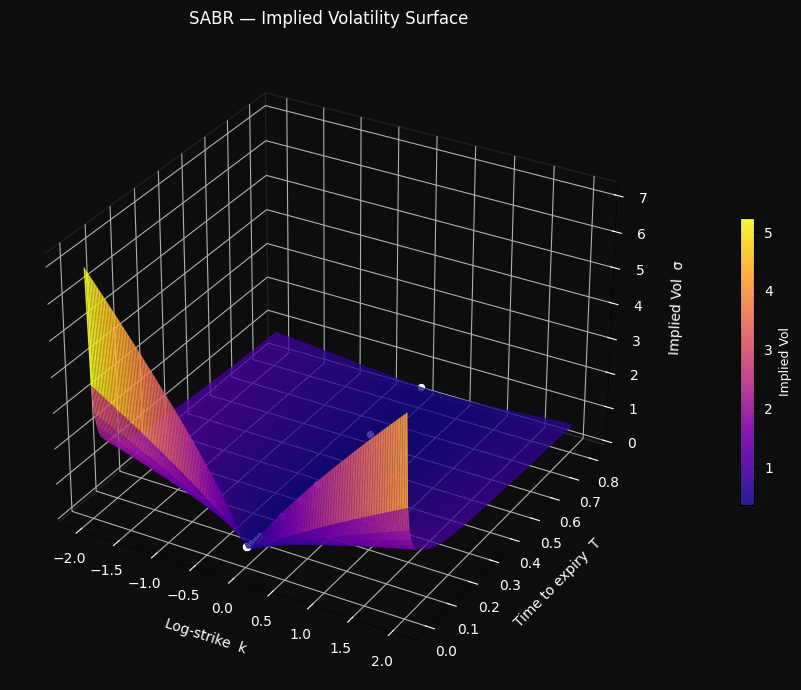

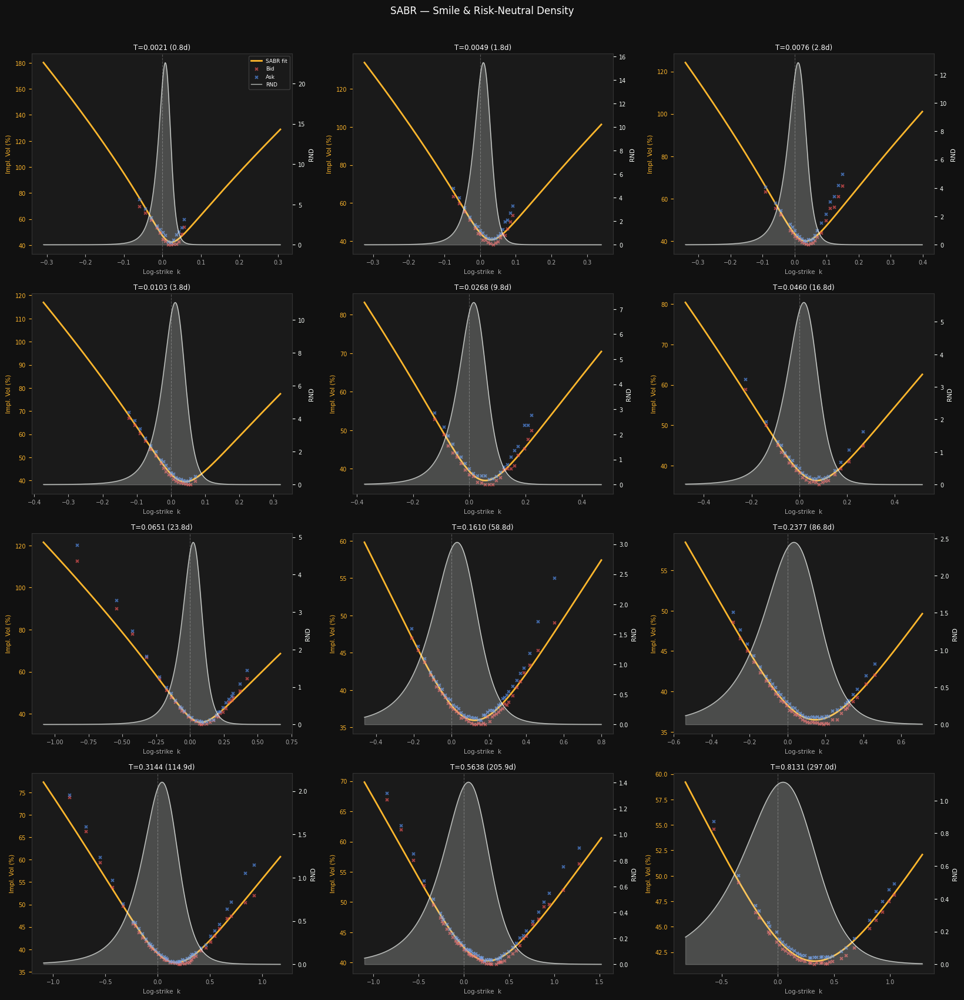

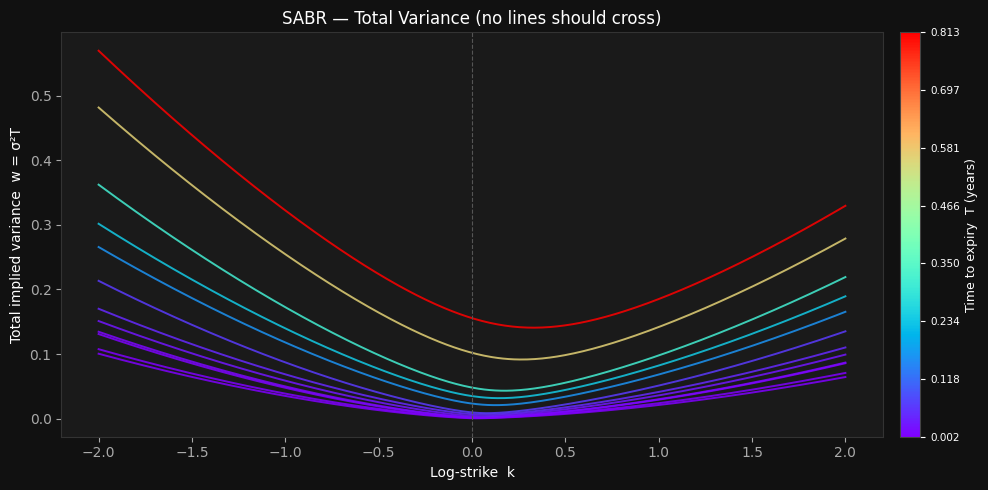

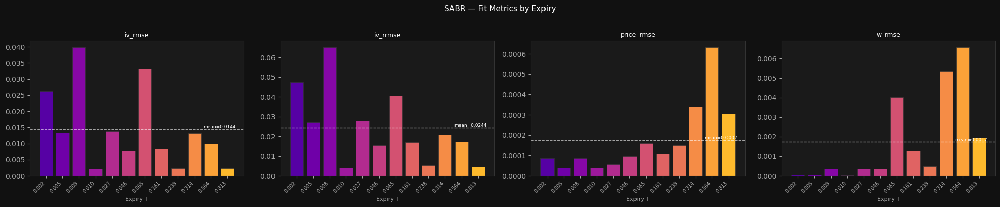

In [6]:
plot_all(res, df_test);

In [19]:
df

,bid_price,ask_price,open_interest,mark_price,creation_timestamp_x,volume,mark_iv,underlying_price,underlying_index,estimated_delivery_price,...,instrument_id,expiration_timestamp_ms,file_timestamp,t,k,w,vega,bid_iv,ask_iv,spread_iv
0,0.0100,0.0110,1974.0,0.010438,1779370865773,1.0,0.5915,2142.81,ETH-25DEC26,2108.22,...,ETH-25DEC26-4800-C,1.798186e+12,2026-05-21 13:41,0.596611,0.806498,0.208738,0.094604,0.586788,0.597328,0.005270
1,0.0016,0.0020,1318.0,0.001782,1779370865773,29.0,0.4874,2108.71,ETH-5JUN26,2108.22,...,ETH-5JUN26-2500-C,1.780646e+12,2026-05-21 13:41,0.040447,0.170214,0.009609,0.019321,0.477616,0.498252,0.010318
2,0.0021,0.0027,2889.0,0.002397,1779370865773,5.0,0.6396,2142.81,ETH-25DEC26,2108.22,...,ETH-25DEC26-7000-C,1.798186e+12,2026-05-21 13:41,0.596611,1.183792,0.244067,0.030603,0.629472,0.649119,0.009824
3,0.0370,0.0380,60.0,0.037430,1779370865773,120.0,0.4725,2109.35,ETH-12JUN26,2108.22,...,ETH-12JUN26-2150-C,1.781251e+12,2026-05-21 13:41,0.059625,0.019088,0.013312,0.096851,0.467915,0.478240,0.005162
4,0.0080,0.0090,23951.0,0.008609,1779370865773,1338.0,0.4759,2109.30,ETH-29MAY26,2108.22,...,ETH-29MAY26-2000-P,1.780042e+12,2026-05-21 13:41,0.021269,-0.053209,0.004817,0.042202,0.461327,0.485105,0.011889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1941,0.0545,0.0560,3859.0,0.055930,1779961373133,304.0,0.5278,2004.52,ETH-25SEP26,1990.39,...,ETH-25SEP26-2400-C,1.790323e+12,2026-05-28 09:42,0.328571,0.180064,0.091531,0.207222,0.520870,0.528124,0.003627
1942,0.0915,0.0940,1200.0,0.093682,1779961373133,80.0,0.5802,2043.42,ETH-26MAR27,1990.39,...,ETH-26MAR27-2900-C,1.806048e+12,2026-05-28 09:42,0.827202,0.350086,0.278463,0.335001,0.573649,0.581125,0.003738
1943,0.0115,0.0125,2047.0,0.012011,1779961373133,60.0,0.5037,1995.83,ETH-31JUL26,1990.39,...,ETH-31JUL26-2600-C,1.785485e+12,2026-05-28 09:42,0.175147,0.264451,0.044437,0.086274,0.497716,0.509314,0.005799
1944,0.0095,0.0105,1955.0,0.010015,1779961373133,1254.0,0.5406,1990.97,ETH-12JUN26,1990.39,...,ETH-12JUN26-1800-P,1.781251e+12,2026-05-28 09:42,0.040900,-0.100835,0.011953,0.050062,0.530307,0.550294,0.009993


In [7]:
check_arbitrage(res)

{'calendar_free': True,
 'butterfly_free': True,
 'calendar_worst': 0.10594467869781331,
 'calendar_worst_k': 0.3807615230460919,
 'calendar_worst_t': 0.12437203177098075,
 'calendar_violation_pct': 0.0,
 'butterfly_worst': 0.030669697679696583,
 'butterfly_worst_k': 2.0,
 'butterfly_worst_t': 0.0021169205986808727,
 'butterfly_violation_pct': 0.0,
 'summary': '──────────────────────────────────────────────────────────────────────────────\n  Static-arbitrage check — SABR\n  Grid: 500 strikes × 200 maturities   (k ∈ [-2, 2],  t ∈ [0.0021, 0.8131])\n  FD steps: dk=0.001  dt=0.0005     tolerance=1e-06\n──────────────────────────────────────────────────────────────────────────────\n  Calendar  [PASS]  worst ∂w/∂t = +1.059e-01  @ (k=+0.381, t=0.1244)  violations: 0.000% of grid\n  Butterfly [PASS]  worst g      = +3.067e-02  @ (k=+2.000, t=0.0021)  violations: 0.000% of grid\n──────────────────────────────────────────────────────────────────────────────'}